# **German Housing Market Analysis**

*A data-driven analysis of rent trends, affordability, and housing pressure across German cities.*

## Project Overview

A comprehensive data-driven analysis of the German residential property market combining city-level transaction data with national macroeconomic indicators.

**Objective** - Analyze residential property price trends and affordability across German cities, and develop models to explain and forecast purchase prices using city-level and macroeconomic drivers.

**Analytical Approach**
1. Descriptive Analysis - What happened to prices and affordability?
2. Diagnostic Analysis - Why did it happen?
3. Predictive Analysis - Can we explain price levels with a model?
4. Forecasting - Where might prices go short-term?

**Datasets**
- City-Level Master Dataset - 30,019 rows, 21 cities, Q1 2005 - Q4 2024
- Macro-Economic Master Dataset - 21 rows, 21 indicators, 2005-2025

**Author**: Aditya Meena, M.Sc. Data Analytics, Universität Hildesheim
[GitHub](https://github.com/meeadi/german-housing-market-analysis)
[Kaggle](https://www.kaggle.com/meenaaditya)
[LinkedIn](https://www.linkedin.com/in/meenaaditya/)



## Setup

In [3]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

# Plot styling

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("All libraries successfully loaded. Plot style applied.")

All libraries successfully loaded. Plot style applied.


In [4]:
# Loading datasets

city = pd.read_csv("data_clean/city_master_dataset.csv", parse_dates=["date"])
macro = pd.read_csv("data_clean/macro_master_dataset.csv")

# Quick check

print("City Dataset:", city.shape)
print("Macro Dataset:", macro.shape)
print()
print(f"City date range: {city["date"].min().date()} to {city["date"].max().date()}")
print(f"Macro year range: {macro["year"].min()} to {macro["year"].max()}")
print()
print("Cities:", sorted(city["city"].unique()))
print("Property types:", list(city["property_type"].unique()))

City Dataset: (30019, 11)
Macro Dataset: (21, 21)

City date range: 2005-01-01 to 2024-10-01
Macro year range: 2005 to 2025

Cities: ['Bochum', 'Bonn', 'Chemnitz', 'Dortmund', 'Dresden', 'Duisburg', 'Düsseldorf', 'Erfurt', 'Frankfurt am Main', 'Hamburg', 'Karlsruhe', 'Kreis Mettmann', 'Köln', 'Leipzig', 'Lübeck', 'München', 'Münster', 'Potsdam', 'Rhein-Erft-Kreis', 'Stuttgart', 'Wiesbaden']
Property types: ['single_family', 'apartment', 'multi_family']


## 1. Descriptive Analysis
*What happened to prices and affordability across German cities?*

This section explores the structure, distribution, and trends in the city-level dataset. We examine price levels, growth rates, property type differences, and geographic patterns.

### Key Findings

- **München stands alone** - With a median price of €7,100/m², nearly double Frankfurt's €3,800, München is structurally in a different market tier. Its IQR of €3,900 means the spread between cheap and expensive München properties exceeds the entire median price of Dortmund.
- **Apartments outgrew every other property type** - Apartment prices rose +137.5% between 2005 and 2024, driven by urbanisation and rental demand. They started as the cheapest property type per m² and ended as the most expensive.
- **The 2022 rate shock hit all property types simultaneously** - For the first time in the dataset, all three property types declined together in 2023. Multi-family saw the sharpest correction (-18.1%), nearly double that of apartments (-11.4%) reflecting investor-owned assets repricing faster than owner-occupied homes.
- **Frankfurt and Hmaburg are more affordability-stressed than München** - In 2024, Frankfurt (38.4%) and Hamburg (38.6%) buyers spent a higher share of income on mortgage costs than München (35.9%) buyers. München prices corrected more sharply post-2022, temporarily relieving stress.
- **The East-West divide is structural but narrowing** - Chemnitz (€1,200/m², 11.9% affordability ratio) and Dortmund (€1,900/m², 21.5%) remain far more accessible than western cities. However Leipzig crossed the 30% affordability stress threshold for the first time in 2022-2023, signalling that Eastern cities are no longer automatically affordable.
- **Market dispersion mirrors price levels** - Higher-priced cities show significantly wider price spreads. Chemnitz has an IQR of just €500, while München's is €3,900 being a homogeneous affordable market vs a highly segmented expensive one.

### 1.1 Dataset Overview

In [21]:
# Basic statistics 

print("City dataset - Descriptive statistics")
print()
print(f"\nTotal observations: {len(city):,}")
print(f"Cities: {city["city"].nunique()}")
print(f"Property types: {city["property_type"].nunique()}")
print(f"Time range: {city["date"].min().date()} to {city["date"].max().date()}")
print(f"Quarters covered: {city["quarter"].nunique()} per year")

print("\nPrice per square metre Statistics (EUR)")
print(city["price_m2"].describe().round(2).to_string())

print("\nObservations per Property Type")
print(city["property_type"].value_counts().to_string())

print("\nObservations per City")
print(city.groupby("city")["price_m2"].count().sort_values(ascending=False).to_string())

print("\nMissing Values")
print(city.isnull().sum().to_string())

City dataset - Descriptive statistics


Total observations: 30,019
Cities: 21
Property types: 3
Time range: 2005-01-01 to 2024-10-01
Quarters covered: 4 per year

Price per square metre Statistics (EUR)
count    30019.00
mean      2907.68
std       1429.87
min        500.00
25%       1900.00
50%       2700.00
75%       3700.00
max      10400.00

Observations per Property Type
property_type
apartment        13715
single_family    10847
multi_family      5457

Observations per City
city
Bochum               2124
Köln                 2124
Stuttgart            2124
Düsseldorf           2124
Frankfurt am Main    2124
Hamburg              2124
Duisburg             2100
Leipzig              1575
Münster              1416
Lübeck               1416
Karlsruhe            1416
Bonn                 1416
Dortmund             1416
Dresden              1404
Erfurt               1380
München               708
Potsdam               708
Chemnitz              708
Wiesbaden             708
Kreis Mettmann  

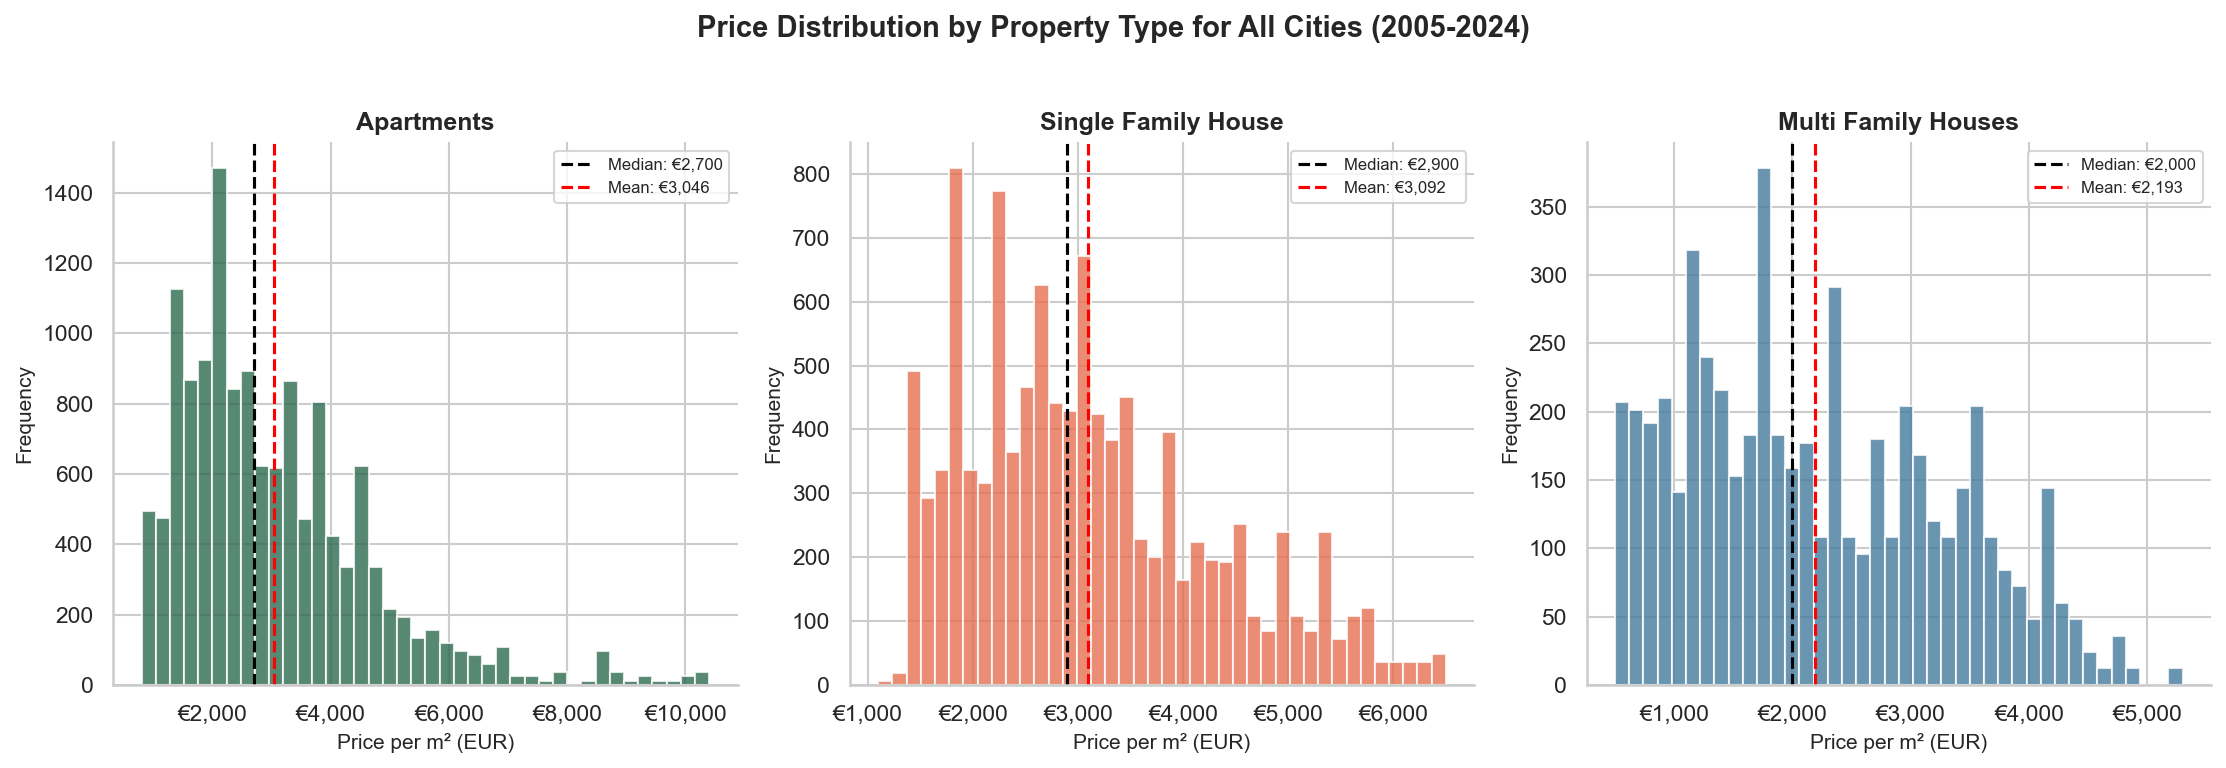

Plot Saved.


In [22]:
# Price distribution overview

fig, axes = plt.subplots(1, 3, figsize=(15,5))

property_types = ["apartment", "single_family", "multi_family"]
titles = ["Apartments", "Single Family House", "Multi Family Houses"]
colors = ["#2D6A4F", "#E76F51", "#457B9D"]

for i, (ptype, title, color) in enumerate(zip(property_types, titles, colors)):
    data = city[city["property_type"] == ptype]["price_m2"]
    axes[i].hist(data, bins=40, color=color, alpha=0.8, edgecolor="white")
    axes[i].axvline(data.median(), color="black", linestyle="--", linewidth=1.5, label=f"Median: €{data.median():,.0f}")
    axes[i].axvline(data.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean: €{data.mean():,.0f}")
    axes[i].set_title(title, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Price per m² (EUR)", fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)
    axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
    axes[i].legend(fontsize=8)

plt.suptitle("Price Distribution by Property Type for All Cities (2005-2024)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/desc_01_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot Saved.")

### 1.2 Average Price by City

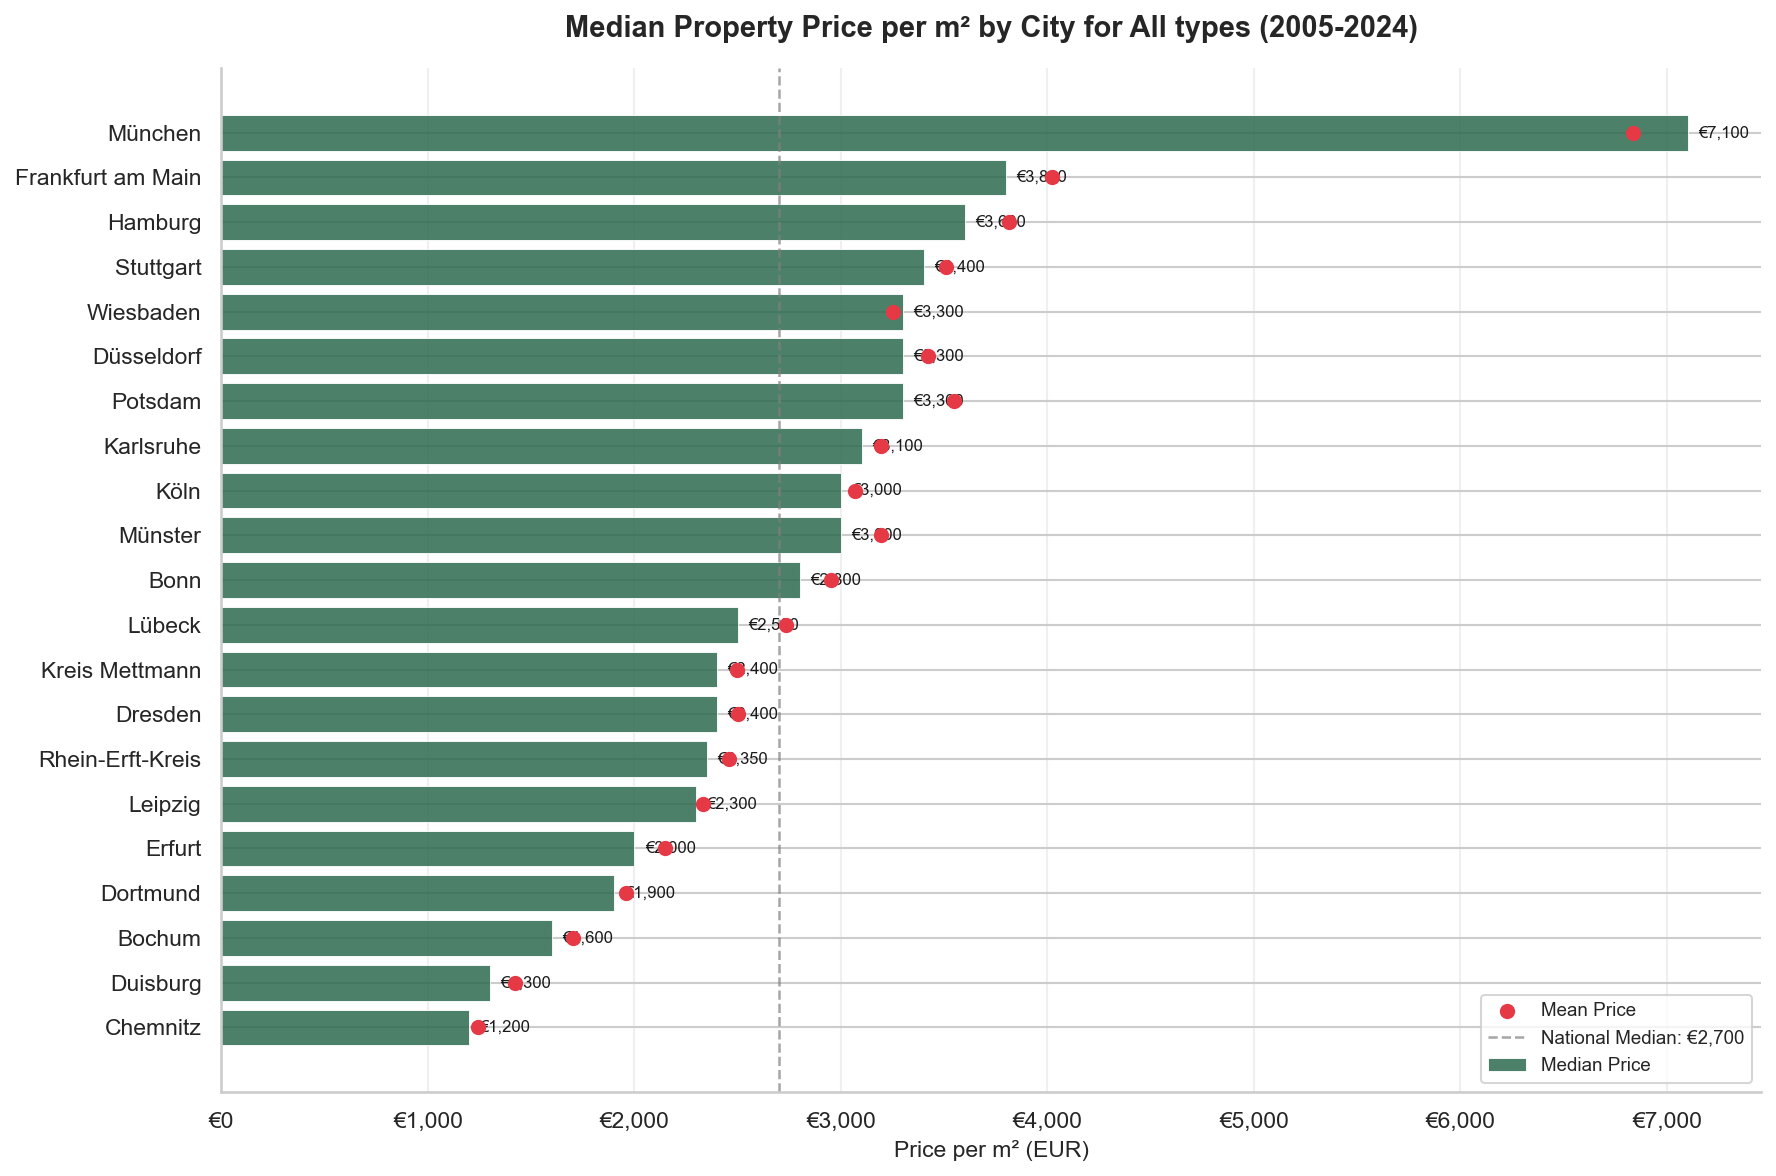

Plot saved.


In [23]:
# Average price per city across entire period for all property types combined

city_avg = city.groupby("city")["price_m2"].agg(mean_price="mean", median_price="median", std_price="std", count="count").round(0).sort_values("median_price", ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(city_avg["city"], city_avg["median_price"], color="#2D6A4F", alpha=0.85, edgecolor="white", linewidth=0.5, label="Median Price")

# Add mean dots

ax.scatter(city_avg["mean_price"], city_avg["city"], color="#E63946", zorder=5, s=40, label="Mean Price")

# Add value labels

for i, (_, row) in enumerate(city_avg.iterrows()):
    ax.text(row["median_price"] + 50, i, f"€{row['median_price']:,.0f}", va="center", fontsize=8, color="#1A1A1A")

# National median reference line

national_median = city["price_m2"].median()
ax.axvline(national_median, color="gray", linestyle="--", alpha=0.7, linewidth=1.2, label=f"National Median: €{national_median:,.0f}")
ax.set_title("Median Property Price per m² by City for All types (2005-2024)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Price per m² (EUR)", fontsize=11)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("figures/desc_02_price_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [24]:
# Print the table

print("Average Price per m² by City (2005–2024)")
print(f"{"City":<25}{"Median":>10}{"Mean":>10}{"Std":>10}")
for _, row in city_avg.sort_values("median_price", ascending=False).iterrows():
    print(f"{row["city"]:<25} " f"€{row['median_price']:>8,.0f} " f"€{row['mean_price']:>8,.0f} " f"€{row['std_price']:>8,.0f}")

Average Price per m² by City (2005–2024)
City                         Median      Mean       Std
München                   €   7,100 €   6,837 €   2,238
Frankfurt am Main         €   3,800 €   4,024 €   1,336
Hamburg                   €   3,600 €   3,816 €   1,426
Stuttgart                 €   3,400 €   3,511 €   1,172
Wiesbaden                 €   3,300 €   3,250 €     940
Düsseldorf                €   3,300 €   3,420 €   1,211
Potsdam                   €   3,300 €   3,547 €   1,161
Karlsruhe                 €   3,100 €   3,193 €     938
Münster                   €   3,000 €   3,193 €     920
Köln                      €   3,000 €   3,067 €   1,021
Bonn                      €   2,800 €   2,950 €     855
Lübeck                    €   2,500 €   2,733 €   1,011
Kreis Mettmann            €   2,400 €   2,498 €     725
Dresden                   €   2,400 €   2,504 €     692
Rhein-Erft-Kreis          €   2,350 €   2,459 €     721
Leipzig                   €   2,300 €   2,333 €     796
Erfurt 

### 1.3 Price Trends Over Time by Property Type

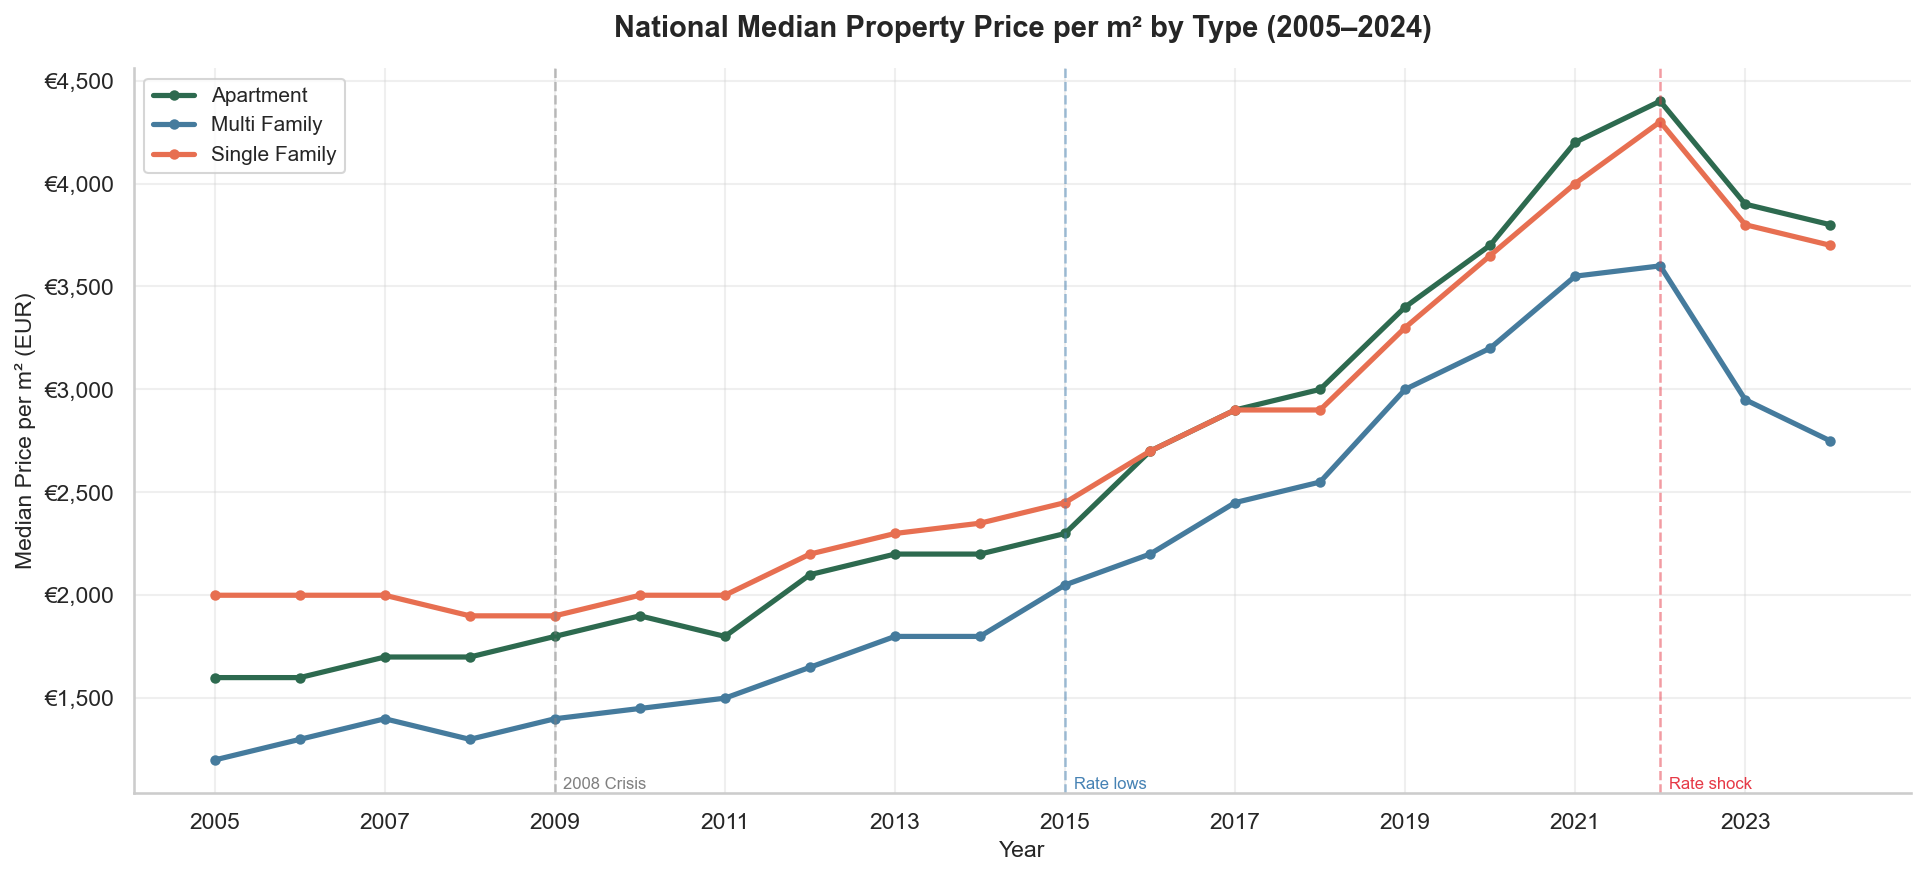

Plot saved.


In [25]:
# Annual average price by property type at National level

price_trend = city.groupby(["year", "property_type"])["price_m2"].median().reset_index()

fig, ax = plt.subplots(figsize=(13,6))

colors = {"apartment": "#2D6A4F", "single_family": "#E76F51", "multi_family": "#457B9D"}

labels = {"apartment": "Apartment", "single_family": "Single Family", "multi_family": "Multi Family"}

for ptype, group in price_trend.groupby("property_type"):
    ax.plot(group["year"], group["price_m2"], marker="o", markersize=4, linewidth=2.5, color=colors[ptype], label=labels[ptype])

# Key event lines

events = {2009: ("2008 Crisis", "gray"), 2015: ("Rate lows", "steelblue"), 2022: ("Rate shock", "#E63946")}

for year, (label, color) in events.items():
    ax.axvline(year, color=color, linestyle="--", alpha=0.5, linewidth=1.2)
    ax.text(year+0.1, ax.get_ylim()[0]*1.02, label, fontsize=8, color=color)

ax.set_title("National Median Property Price per m² by Type (2005–2024)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Median Price per m² (EUR)", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.set_xticks(range(2005, 2025, 2))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/desc_03_price_trend_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [26]:
# Calculate growth rates for each property type

print("Price Growth by Property Type")
print()

for ptype in ["apartment", "single_family", "multi_family"]:
    data = price_trend[price_trend["property_type"] == ptype].copy()

    price_2005 = data[data["year"] == 2005]["price_m2"].values[0]
    price_2015 = data[data["year"] == 2015]["price_m2"].values[0]
    price_2022 = data[data["year"] == 2022]["price_m2"].values[0]
    price_2024 = data[data["year"] == 2024]["price_m2"].values[0]

    growth_total = ((price_2024 - price_2005) / price_2005)*100
    growth_boom = ((price_2022 - price_2015) / price_2015)*100
    correction = ((price_2024 - price_2022) / price_2022)*100

    print(f"\n{labels[ptype]}")
    print(f"2005 price: €{price_2005:,.0f}/m²")
    print(f"2022 peak: €{price_2022:,.0f}/m²")
    print(f"2024 current: €{price_2024:,.0f}/m²")
    print(f"Total growth (2005-2024): {growth_total:+.1f}%")
    print(f"Boom growth (2015-2022): {growth_boom:+.1f}%")
    print(f"Correction (2022-2024): {correction:+.1f}%")

Price Growth by Property Type


Apartment
2005 price: €1,600/m²
2022 peak: €4,400/m²
2024 current: €3,800/m²
Total growth (2005-2024): +137.5%
Boom growth (2015-2022): +91.3%
Correction (2022-2024): -13.6%

Single Family
2005 price: €2,000/m²
2022 peak: €4,300/m²
2024 current: €3,700/m²
Total growth (2005-2024): +85.0%
Boom growth (2015-2022): +75.5%
Correction (2022-2024): -14.0%

Multi Family
2005 price: €1,200/m²
2022 peak: €3,600/m²
2024 current: €2,750/m²
Total growth (2005-2024): +129.2%
Boom growth (2015-2022): +75.6%
Correction (2022-2024): -23.6%


### 1.4 Year-on-year Price Growth Rate

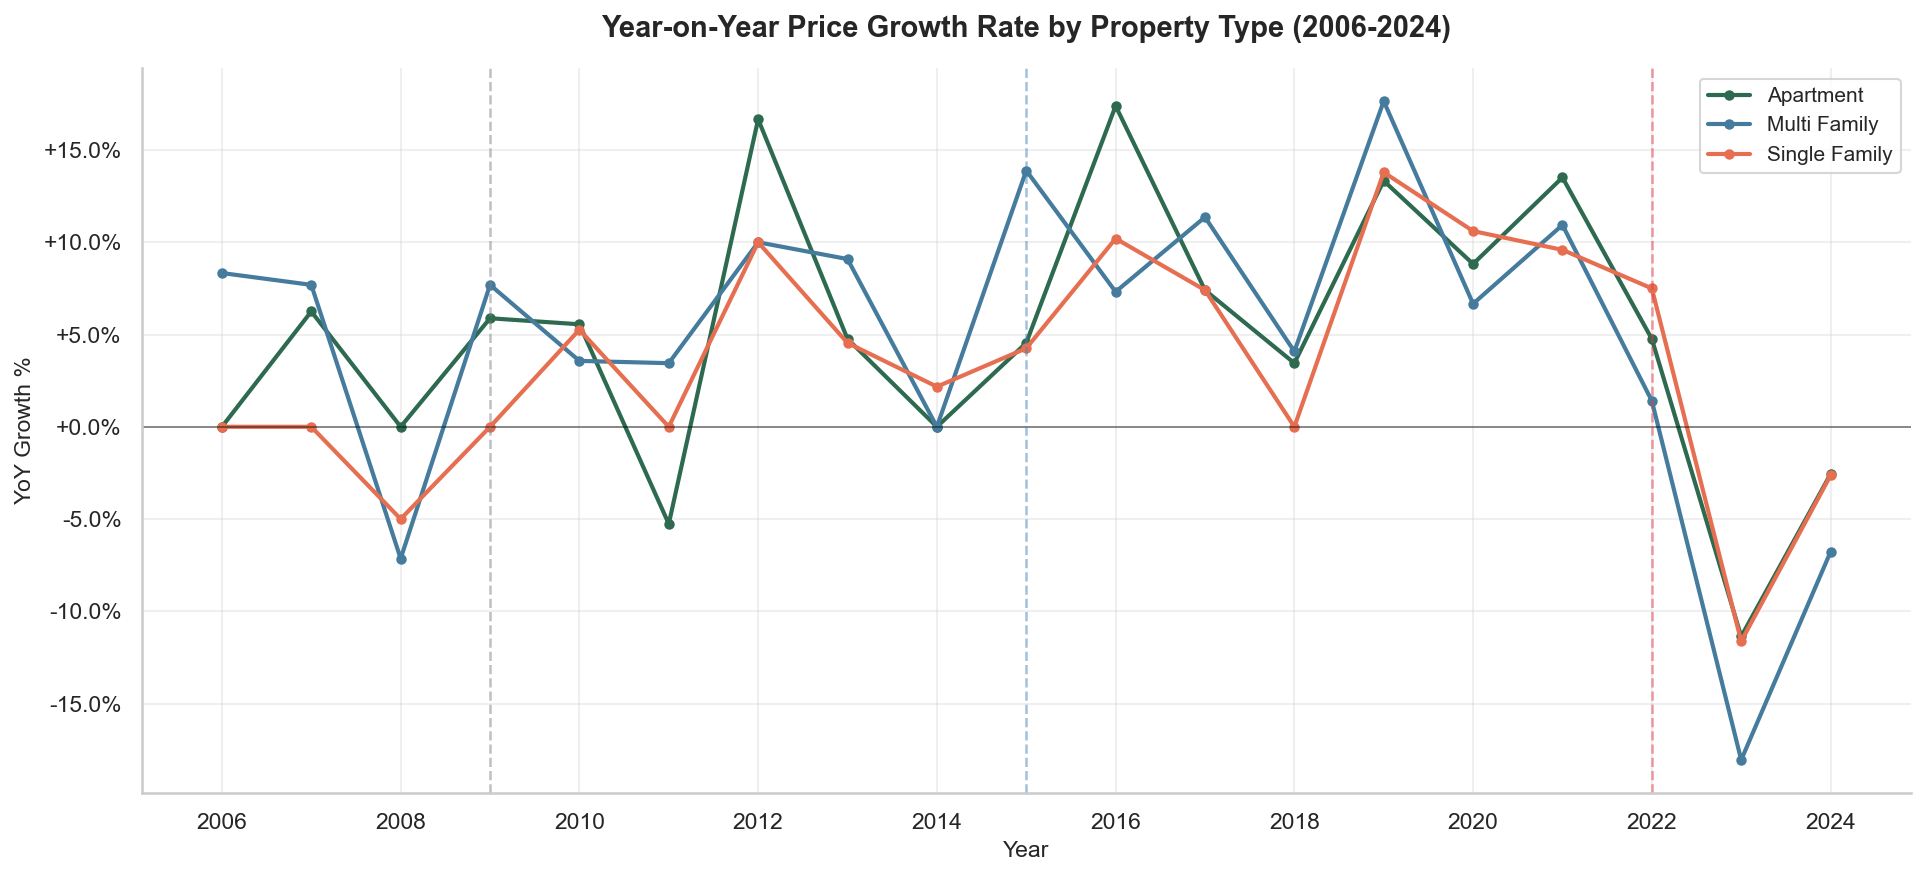

Plot saved.


In [27]:
# YoY growth rate by property type

yoy = city.groupby(["year", "property_type"])["price_m2"].median().reset_index()
yoy["yoy_growth"] = yoy.groupby("property_type")["price_m2"].pct_change()*100
yoy = yoy.dropna(subset=["yoy_growth"])

fig, ax = plt.subplots(figsize=(13,6))

for ptype, group in yoy.groupby("property_type"):
    ax.plot(group["year"], group["yoy_growth"], marker="o", markersize=4, linewidth=2, color=colors[ptype], label=labels[ptype])

# Zero line

ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)

# Shade positive and negative

ax.fill_between(yoy["year"].unique(), 0, 0, alpha=0)

# Event lines

for year, (label, color) in events.items():
    ax.axvline(year, color=color, linestyle="--", alpha=0.5, linewidth=1.2)

ax.set_title("Year-on-Year Price Growth Rate by Property Type (2006-2024)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("YoY Growth %", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:+.1f}%"))
ax.set_xticks(range(2006, 2025, 2))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/desc_04_yoy_growth.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [28]:
# Peak growth years per property type

print("Peak Growth Years by Property Type")
print()

for ptype in ["apartment", "single_family", "multi_family"]:
    data = yoy[yoy["property_type"] == ptype]
    peak = data.loc[data["yoy_growth"].idxmax()]
    trough = data.loc[data["yoy_growth"].idxmin()]

    print(f"\n{labels[ptype]}")
    print(f"Fastest growth: {int(peak["year"])}" f"({peak["yoy_growth"]:+.1f}%)")
    print(f"Sharpest decline: {int(trough["year"])}" f"({trough["yoy_growth"]:+.1f}%)")

Peak Growth Years by Property Type


Apartment
Fastest growth: 2016(+17.4%)
Sharpest decline: 2023(-11.4%)

Single Family
Fastest growth: 2019(+13.8%)
Sharpest decline: 2023(-11.6%)

Multi Family
Fastest growth: 2019(+17.6%)
Sharpest decline: 2023(-18.1%)


### 1.5 Price Dispersion by City representing Market Inequality

**City Metrics Column** - The "avg_price_m2", "med_price_m2", "p25_price_m2", and "p75_price_m2" columns from the City Metrics source appear to use a different unit scale than "price_m2" from GREIX and are therefore excluded from direct price comparisons. They may be useful for relative within-city dispersion analysis only, for instance check out the analysis below.

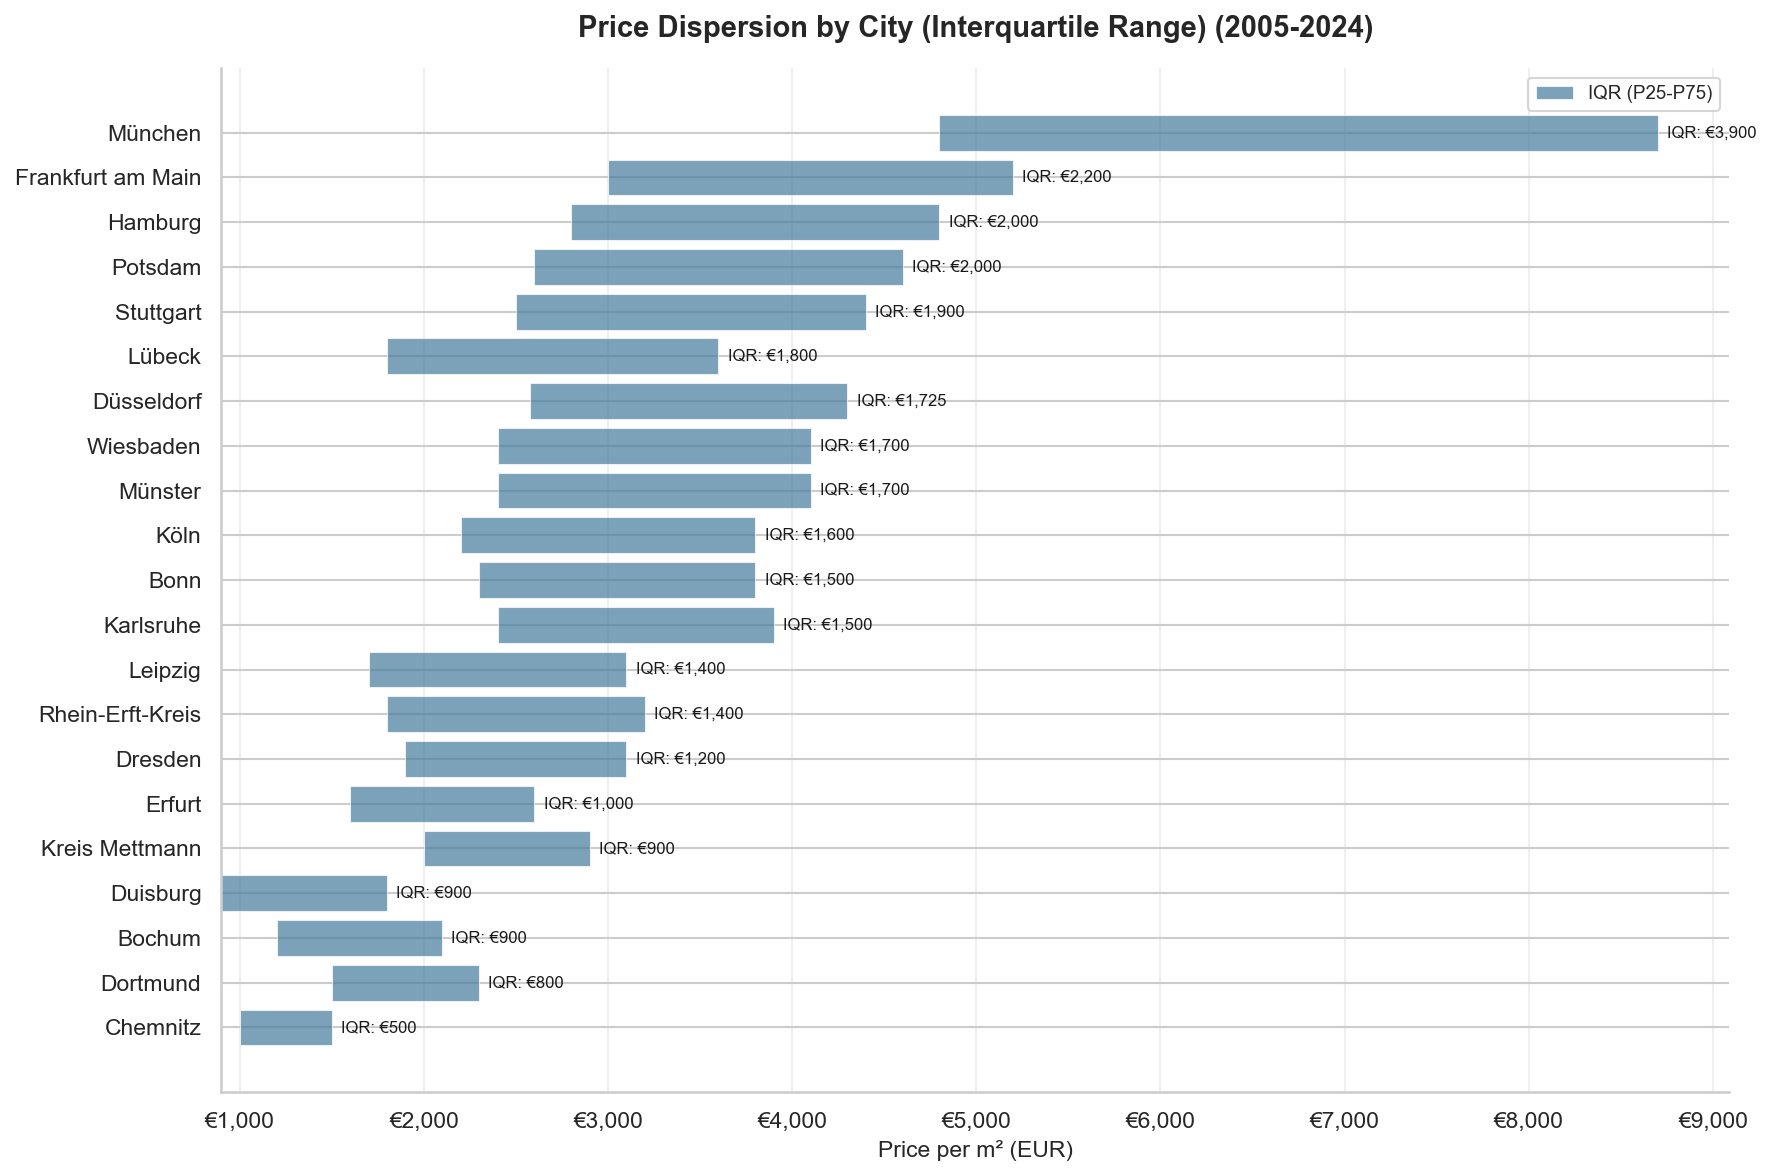

Plot saved.


In [29]:
# Price dispersion (p75 vs p25 spread per city), shows inequality within each city's market, only available from 2012 onwards

dispersion = city.groupby("city")["price_m2"].agg(median_price="median", std_price="std", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)).round(0).reset_index()
dispersion["iqr"] = dispersion["q75"] - dispersion["q25"]
dispersion = dispersion.sort_values("iqr", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12,8))
ax.barh(dispersion["city"], dispersion["iqr"], left=dispersion["q25"], color="#457B9D", alpha=0.7, edgecolor="white", linewidth=0.5, label="IQR (P25-P75)")

for i, (_, row) in enumerate(dispersion.iterrows()):
    ax.text(row["q75"]+50, i, f"IQR: €{row['iqr']:,.0f}", va="center", fontsize=8, color="#1A1A1A")

ax.set_title("Price Dispersion by City (Interquartile Range) (2005-2024)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Price per m² (EUR)", fontsize=11)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("figures/desc_05_price_dispersion.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [30]:
print("Price Dispersion by City (Interquartile Range) (2005-2024)")
print()
print(f"{"City":<25} {"Median":>8} {"P25":>8} {"P75":>8} {"IQR":>8} {"Std":>8}")
print()

for _, row in dispersion.sort_values("iqr", ascending=False).iterrows():
    print(f"{row["city"]:<25}  " f"€{row['median_price']:>6,.0f}  " f"€{row['q25']:>6,.0f}  " f"€{row['q75']:>6,.0f}  " f"€{row['iqr']:>6,.0f}  " f"€{row['std_price']:>6,.0f}  ")

Price Dispersion by City (Interquartile Range) (2005-2024)

City                        Median      P25      P75      IQR      Std

München                    € 7,100  € 4,800  € 8,700  € 3,900  € 2,238  
Frankfurt am Main          € 3,800  € 3,000  € 5,200  € 2,200  € 1,336  
Hamburg                    € 3,600  € 2,800  € 4,800  € 2,000  € 1,426  
Potsdam                    € 3,300  € 2,600  € 4,600  € 2,000  € 1,161  
Stuttgart                  € 3,400  € 2,500  € 4,400  € 1,900  € 1,172  
Lübeck                     € 2,500  € 1,800  € 3,600  € 1,800  € 1,011  
Düsseldorf                 € 3,300  € 2,575  € 4,300  € 1,725  € 1,211  
Wiesbaden                  € 3,300  € 2,400  € 4,100  € 1,700  €   940  
Münster                    € 3,000  € 2,400  € 4,100  € 1,700  €   920  
Köln                       € 3,000  € 2,200  € 3,800  € 1,600  € 1,021  
Bonn                       € 2,800  € 2,300  € 3,800  € 1,500  €   855  
Karlsruhe                  € 3,100  € 2,400  € 3,900  € 1,500  € 

### 1.6 Affordability Trends Over Time

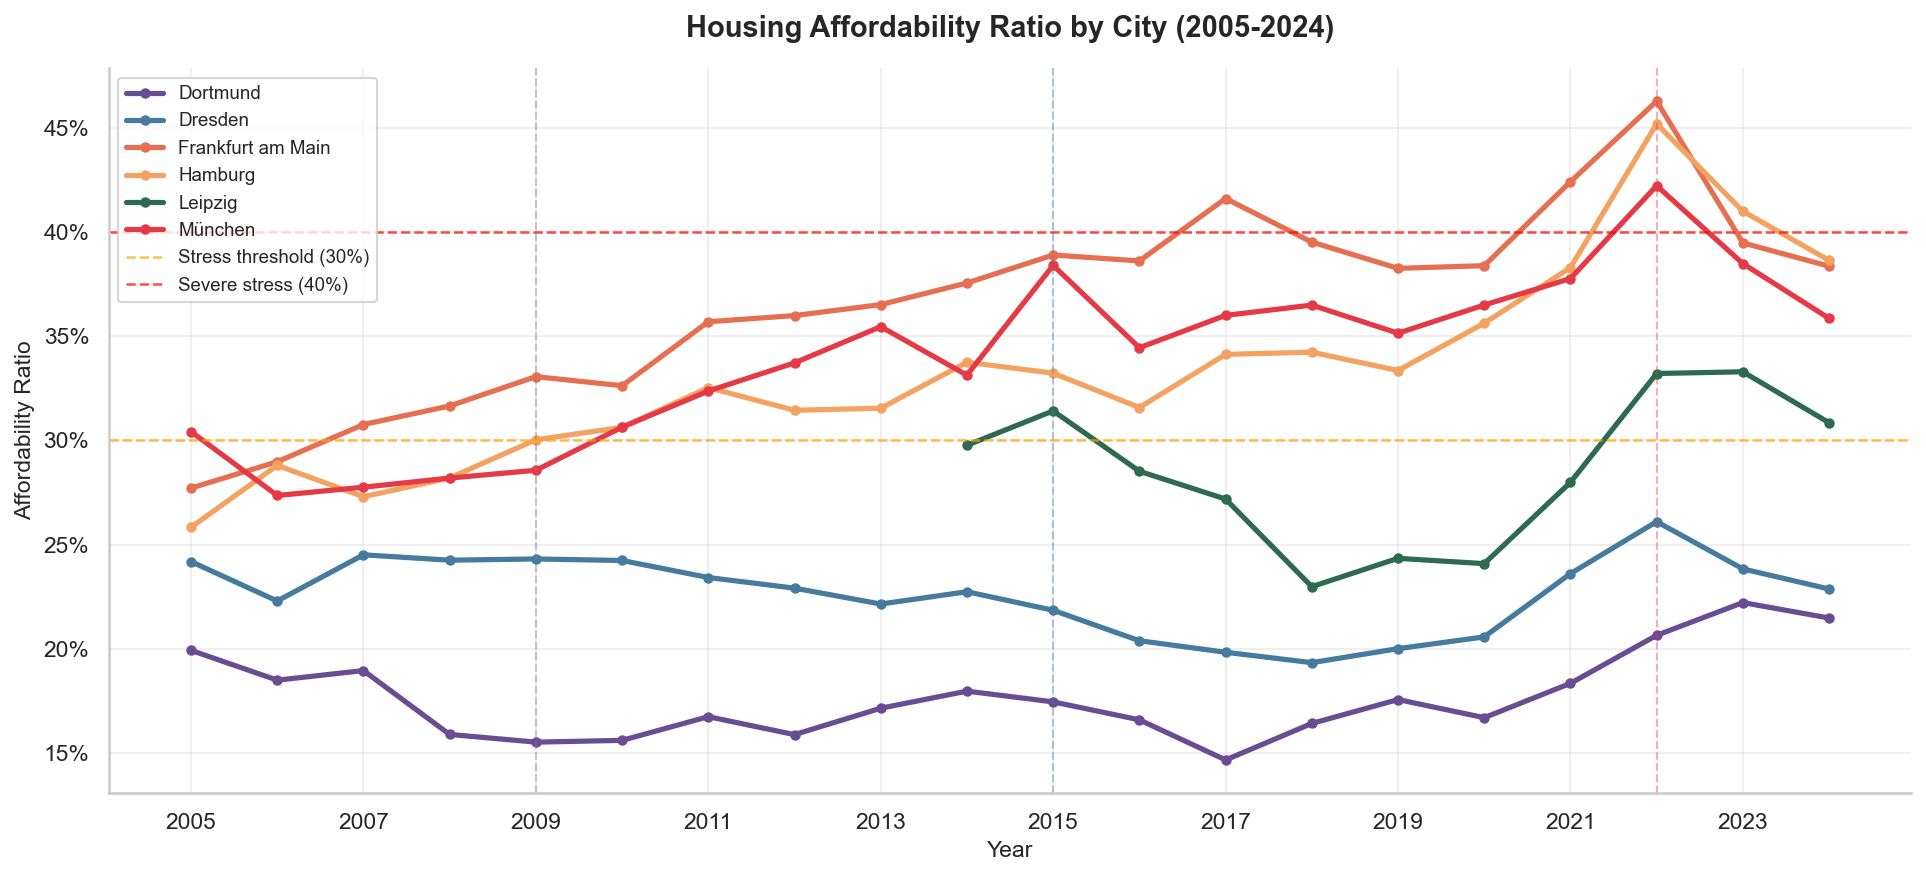

Plot saved.


In [31]:
# Affordability ratio over time for selected cities

afford = city.dropna(subset=["affordability_ratio"]).copy()
afford_annual = afford.groupby(["year", "city"])["affordability_ratio"].mean().reset_index()

# Select representative cities across the spectrum

selected = ["München", "Frankfurt am Main", "Hamburg", "Leipzig", "Dresden", "Dortmund"]
afford_selected = afford_annual[afford_annual["city"].isin(selected)]

fig, ax = plt.subplots(figsize=(13,6))
city_colors = {"München": "#E63946", "Frankfurt am Main": "#E76F51", "Hamburg": "#F4A261", "Leipzig": "#2D6A4F", "Dresden": "#457B9D", "Dortmund": "#6A4C93"}

for city_name, group in afford_selected.groupby("city"):
    ax.plot(group["year"], group["affordability_ratio"], marker="o", markersize=4, linewidth=2.5, color=city_colors[city_name], label=city_name)

# Affordability threshold lines

ax.axhline(0.30, color="orange", linestyle="--", alpha=0.7, linewidth=1.2, label="Stress threshold (30%)")
ax.axhline(0.40, color="red", linestyle="--", alpha=0.7, linewidth=1.2, label="Severe stress (40%)")

# Event lines

for year, (label, color) in events.items():
    ax.axvline(year, color=color, linestyle="--", alpha=0.4, linewidth=1)

ax.set_title("Housing Affordability Ratio by City (2005-2024)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Affordability Ratio", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xticks(range(2005, 2025, 2))
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/desc_06_affordability_trends.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [32]:
# Latest affordability ratios

latest_afford = afford_annual[afford_annual["year"] == afford_annual["year"].max()].sort_values("affordability_ratio", ascending=False)

print(f"Affordability Ratio {afford_annual["year"].max()}" f"(latest available)")
print()
print(f"{"City":<25} {"Ratio":>8} {"Status":>12}")
print()

for _, row in latest_afford.iterrows():
    ratio = row["affordability_ratio"]
    if ratio >= 0.40:
        status = "Severe"
    elif ratio >= 0.30:
        status = "Stressed"
    else:
        status = "Moderate"
    print(f"{row["city"]:<25}   {ratio:>7.1%}   {status}")

Affordability Ratio 2024(latest available)

City                         Ratio       Status

Hamburg                       38.6%   Stressed
Frankfurt am Main             38.4%   Stressed
München                       35.9%   Stressed
Potsdam                       34.1%   Stressed
Lübeck                        31.3%   Stressed
Leipzig                       30.9%   Stressed
Düsseldorf                    29.8%   Moderate
Köln                          29.7%   Moderate
Wiesbaden                     28.7%   Moderate
Stuttgart                     26.8%   Moderate
Karlsruhe                     26.5%   Moderate
Erfurt                        24.1%   Moderate
Münster                       23.9%   Moderate
Bonn                          23.2%   Moderate
Dresden                       22.9%   Moderate
Dortmund                      21.5%   Moderate
Bochum                        20.0%   Moderate
Duisburg                      16.6%   Moderate
Chemnitz                      11.9%   Moderate


## 2. Diagnostic Analysis

*Why did prices move the way they did?*

This section investigates the relationship between national macroeconomic indicators and city-level property prices. We connect the macro dataset to city-level trends to identify the key drivers of price movements across the study period. 

### Key Findings

- **Mortgage rate relationship broke down after 2015** - Pre-2015, mortgage rates and prices had a near-perfect inverse correlation (-0.977). Post-2015, this correlation turned positive (+0.22) as demand momentum and supply constraints became the dominant drivers as rates kept falling, but prices accelerated beyond what financing costs alone could explain.
- **Supply collapse cushioned the price correction** - Residential building permits fell 46.6% from peak to 2024, yet prices only corrected 15.9%. Without the supply constraint, a demand-driven correction of this magnitude would typically produce a 30-40% price decline. Germany's housing shortage prevented a deeper crash.
- **Half the nominal price boom was inflation** - Nominal prices rose +91.7% since 2010, but real (inflation-adjusted) prices rose only +41.5%. Earnings grew +43.6% over the same period meaning real purchasing power broadly kept pace with real prices by 2024. However the path mattered as real prices outpaced earnings by up to 40 index points during 2015-2022, the period of peak affordability stress.
- **Building permits are the supply-side leading indicator** - YoY change in permits correlate to -0.653 with YoY price changes, representing years of falling construction preceded years of accelerating prices. The 2007-2010 permit collapse anticipated the 2012-2016 price surge, and the 2022-2024 collaphse signals continued price stickiness ahead.

- **Wohngeld reform complicates affordability stress measurement** - The 2023 Wohngeld-Plus reform doubled recipients via expanded eligibility rather than genuine stress increase, creating a structural break in the series. Pre-reform, declining Wohngeld recipients masked worsening affordability as rising income offset rising prices for most households until the 2022 rate shock hit both simultaneously.

### 2.1 Macro Indicator Correlation Matrix

Correlations between national macroeconomic variables reveal which indicators move together and set up the casual analysis that follows.

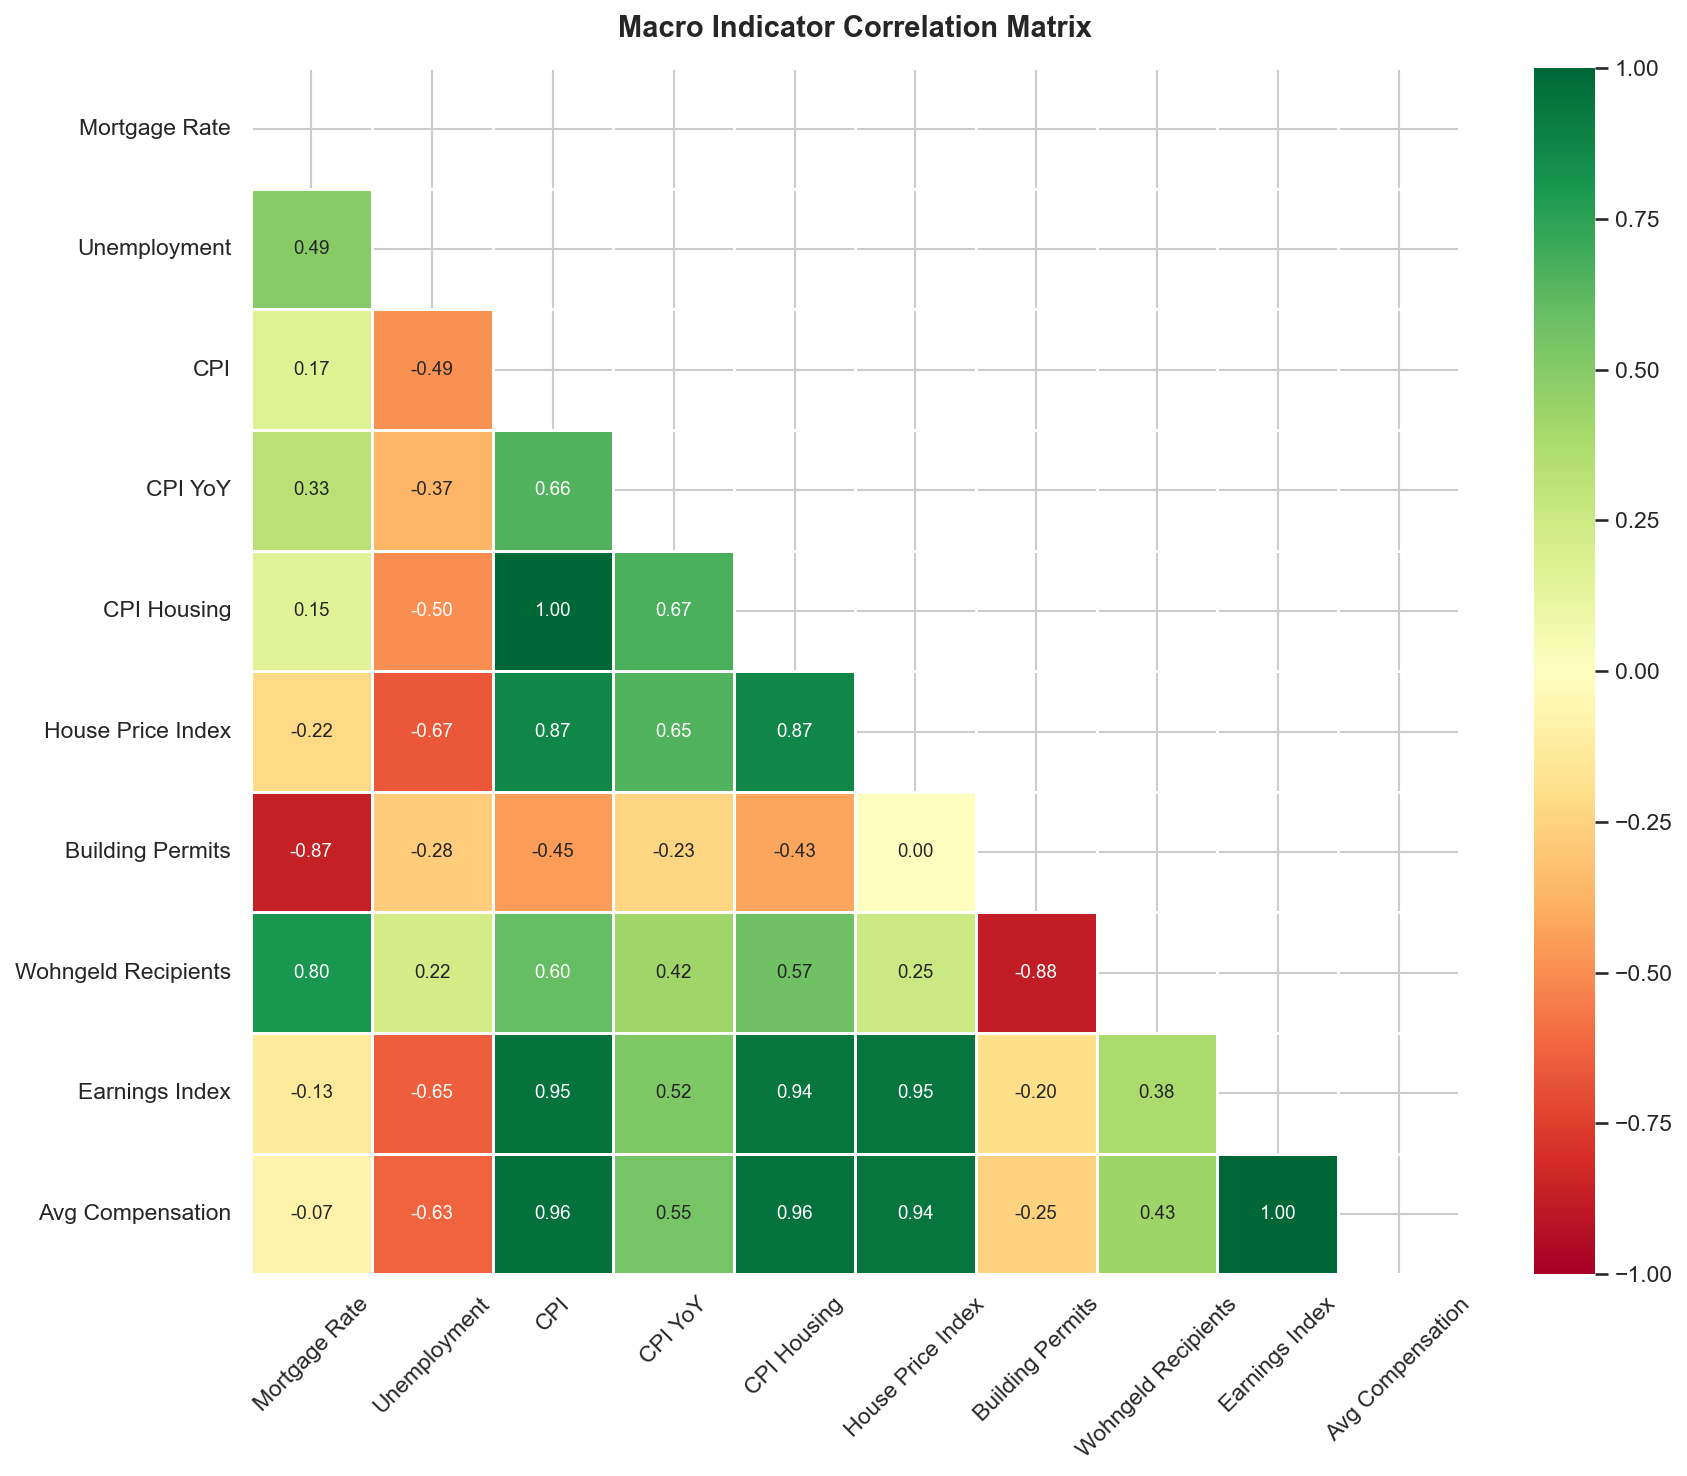

Plot saved.


In [33]:
# Select relevant macro indicators for correlation analysis

macro_corr = macro[["year", "mortgage_rate_avg_pct", "unemployment_rate_pct", "cpi_headline", "cpi_yoy_change_pct",
              "cpi_housing", "hpi_overall", "building_permits_residential", "wohngeld_total",
              "earnings_index_monthly_with_bonus", "avg_compensation_per_employee_eur"]].dropna()
macro_corr = macro_corr.rename(columns={"mortgage_rate_avg_pct": "Mortgage Rate",
                                        "unemployment_rate_pct": "Unemployment",
                                        "cpi_headline": "CPI",
                                        "cpi_yoy_change_pct": "CPI YoY",
                                        "cpi_housing": "CPI Housing",
                                        "hpi_overall": "House Price Index",
                                        "building_permits_residential": "Building Permits",
                                        "wohngeld_total": "Wohngeld Recipients",
                                        "earnings_index_monthly_with_bonus": "Earnings Index",
                                        "avg_compensation_per_employee_eur": "Avg Compensation"}).drop(columns=["year"])
corr_matrix = macro_corr.corr()

fig, ax = plt.subplots(figsize=(12,10))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="white", ax=ax, annot_kws={"size":9})

ax.set_title("Macro Indicator Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("figures/diag_01_macro_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

### 2.2 Mortgage Rate vs City Price Growth

The relationship between financing costs and property prices is the central diagnostic story. Here we quantify the correlation at city level and examine the lag between rate change and price responses.

In [34]:
# Join macro to city data on year

city_macro = city.merge(macro[["year", "mortgage_rate_avg_pct", "unemployment_rate_pct",
                               "cpi_headline", "cpi_yoy_change_pct", "hpi_overall",
                               "building_permits_residential", "wohngeld_total", "earnings_index_monthly_with_bonus"]], on="year", how="left")

print("Joined dataset shape:", city_macro.shape)
print("Columns:", city_macro.columns.tolist())

Joined dataset shape: (30019, 19)
Columns: ['city', 'date', 'year', 'quarter', 'property_type', 'price_m2', 'avg_price_m2', 'med_price_m2', 'p75_price_m2', 'p25_price_m2', 'affordability_ratio', 'mortgage_rate_avg_pct', 'unemployment_rate_pct', 'cpi_headline', 'cpi_yoy_change_pct', 'hpi_overall', 'building_permits_residential', 'wohngeld_total', 'earnings_index_monthly_with_bonus']


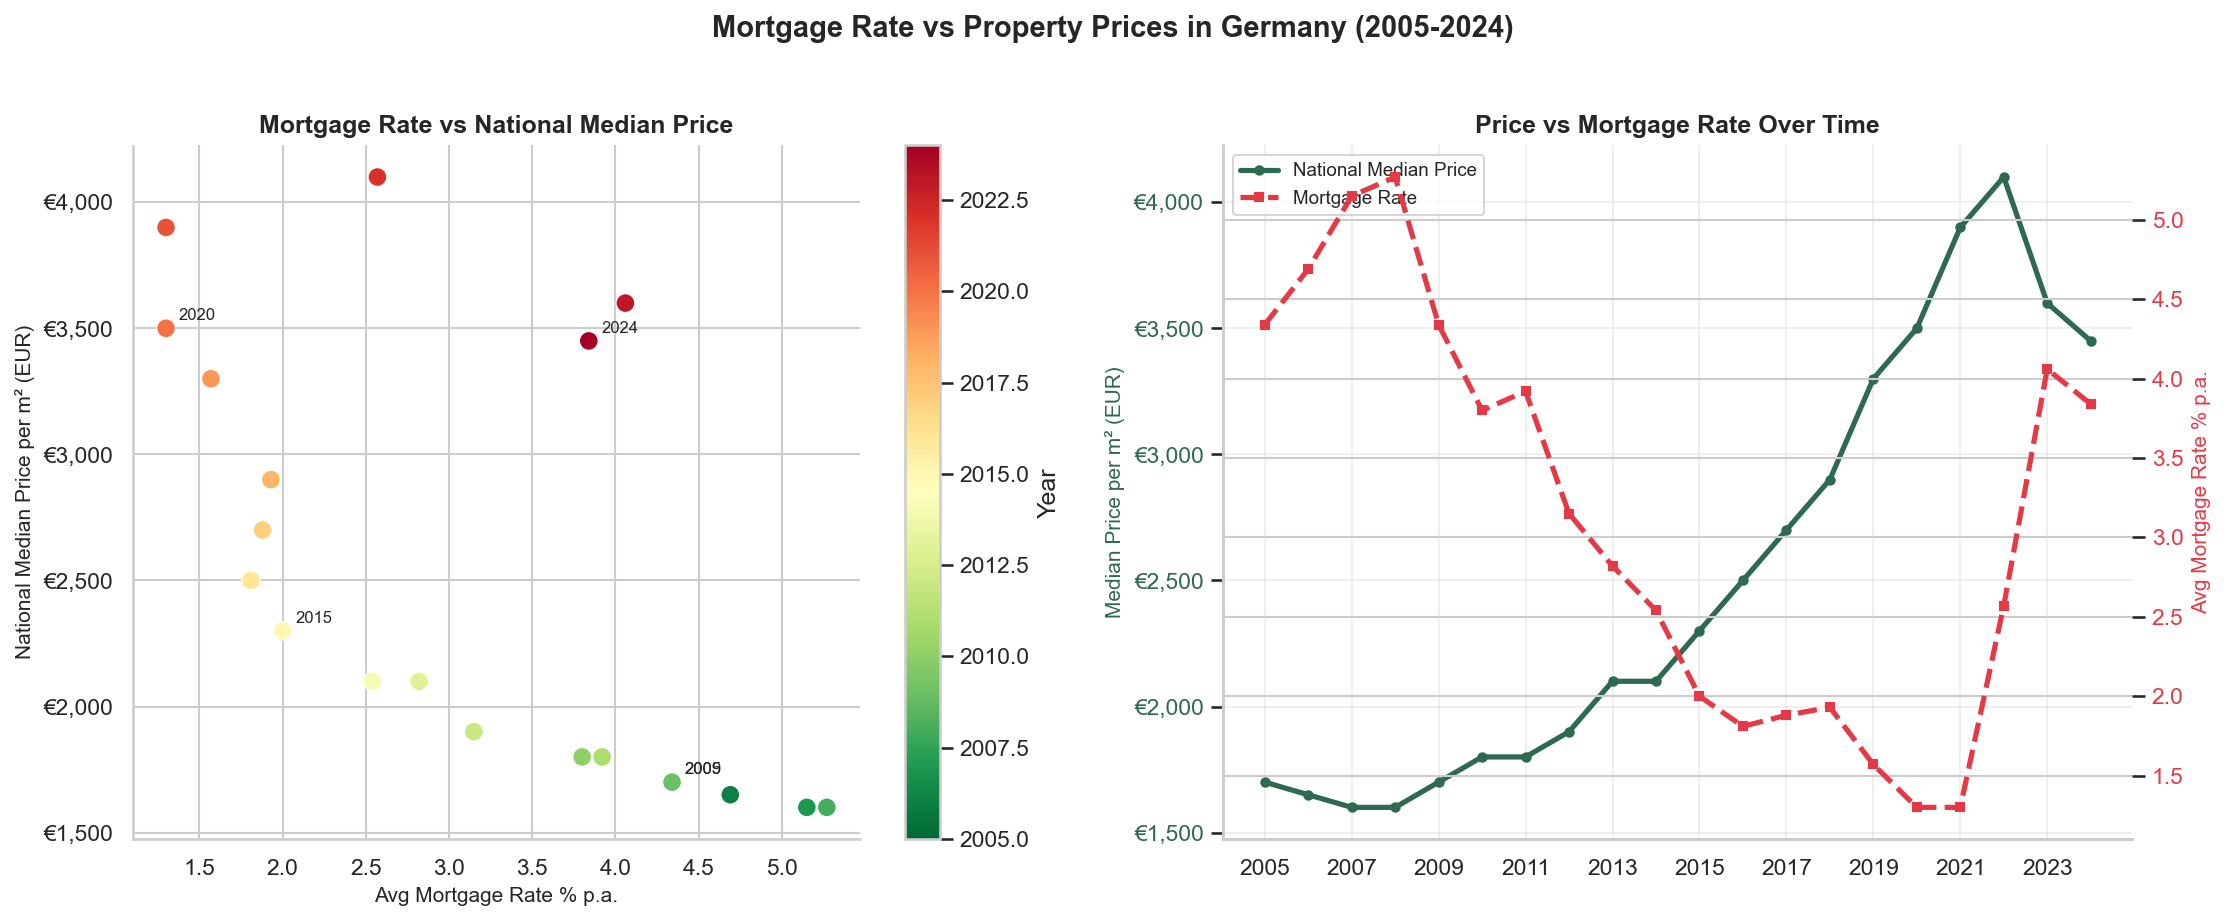

Plot saved.


In [12]:
# Annual city average price vs national mortgage rate

city_macro_annual = city_macro.groupby(["year", "city"]).agg(avg_price=("price_m2", "median"), mortgage_rate=("mortgage_rate_avg_pct", "first")).reset_index()

# National average price across all cities

national_annual = city_macro.groupby("year").agg(avg_price=("price_m2", "median"), mortgage_rate=("mortgage_rate_avg_pct", "first")).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15,6))

# Left scatter

ax1 = ax[0]
scatter = ax1.scatter(national_annual["mortgage_rate"], national_annual["avg_price"], c=national_annual["year"], cmap="RdYlGn_r", s=80, zorder=5, edgecolor="white", linewidth=0.5)

# Annotate key years

for _, row in national_annual[national_annual["year"].isin([2005, 2009, 2015, 2020, 2024])].iterrows():
    ax1.annotate(str(int(row["year"])), (row["mortgage_rate"], row["avg_price"]), textcoords="offset points", xytext=(6,4), fontsize=8)

plt.colorbar(scatter, ax=ax1, label="Year")
ax1.set_title("Mortgage Rate vs National Median Price", fontsize=12, fontweight="bold")
ax1.set_xlabel("Avg Mortgage Rate % p.a.", fontsize=10)
ax1.set_ylabel("National Median Price per m² (EUR)", fontsize=10)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

# Right dual axis time series

ax2 = ax[1]
color_price = "#2D6A4F"
color_rate = "#E63946"

ax2.plot(national_annual["year"], national_annual["avg_price"], color=color_price, linewidth=2.5, marker="o", markersize=4, label="National Median Price")
ax2.set_ylabel("Median Price per m² (EUR)", fontsize=10, color=color_price)
ax2.tick_params(axis="y", labelcolor=color_price)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

ax3 = ax2.twinx()
ax3.plot(national_annual["year"], national_annual["mortgage_rate"], color=color_rate, linewidth=2.5, marker="s", markersize=4, linestyle="--", label="Mortgage Rate")
ax3.set_ylabel("Avg Mortgage Rate % p.a.", fontsize=10, color=color_rate)
ax3.tick_params(axis="y", labelcolor=color_rate)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")
ax2.set_title("Price vs Mortgage Rate Over Time", fontsize=12, fontweight="bold")
ax2.set_xticks(range(2005,2025,2))
ax2.grid(True, alpha=0.3)

plt.suptitle("Mortgage Rate vs Property Prices in Germany (2005-2024)", fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("figures/diag_02_mortgage_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [13]:
# Correlation coefficient between mortgage rate and price 

corr = national_annual["mortgage_rate"].corr(national_annual["avg_price"])
print(f"Pearson correlation, Mortgage Rate vs Price: {corr:.3f}")

# Split pre/post 2015

pre2015 = national_annual[national_annual["year"] <= 2015]
post2015 = national_annual[national_annual["year"] > 2015]
corr_pre = pre2015["mortgage_rate"].corr(pre2015["avg_price"])
corr_post = post2015["mortgage_rate"].corr(post2015["avg_price"])

print(f"Pre-2015 correlation: {corr_pre:.3f}")
print(f"Post-2015 correlation: {corr_post:.3f}")
print()
print("Note: Post-2015 dhows the inverse relationship more clearly as cheap money directly fuelled price acceleration.")

Pearson correlation, Mortgage Rate vs Price: -0.616
Pre-2015 correlation: -0.977
Post-2015 correlation: 0.220

Note: Post-2015 dhows the inverse relationship more clearly as cheap money directly fuelled price acceleration.


### 2.3 Housing Supply vs Price Growth

Building permits serve as a proxy for housing supply. The supply constraint hypothesis suggests that falling supply amplified price growth and cushioned the post-2022 correction.

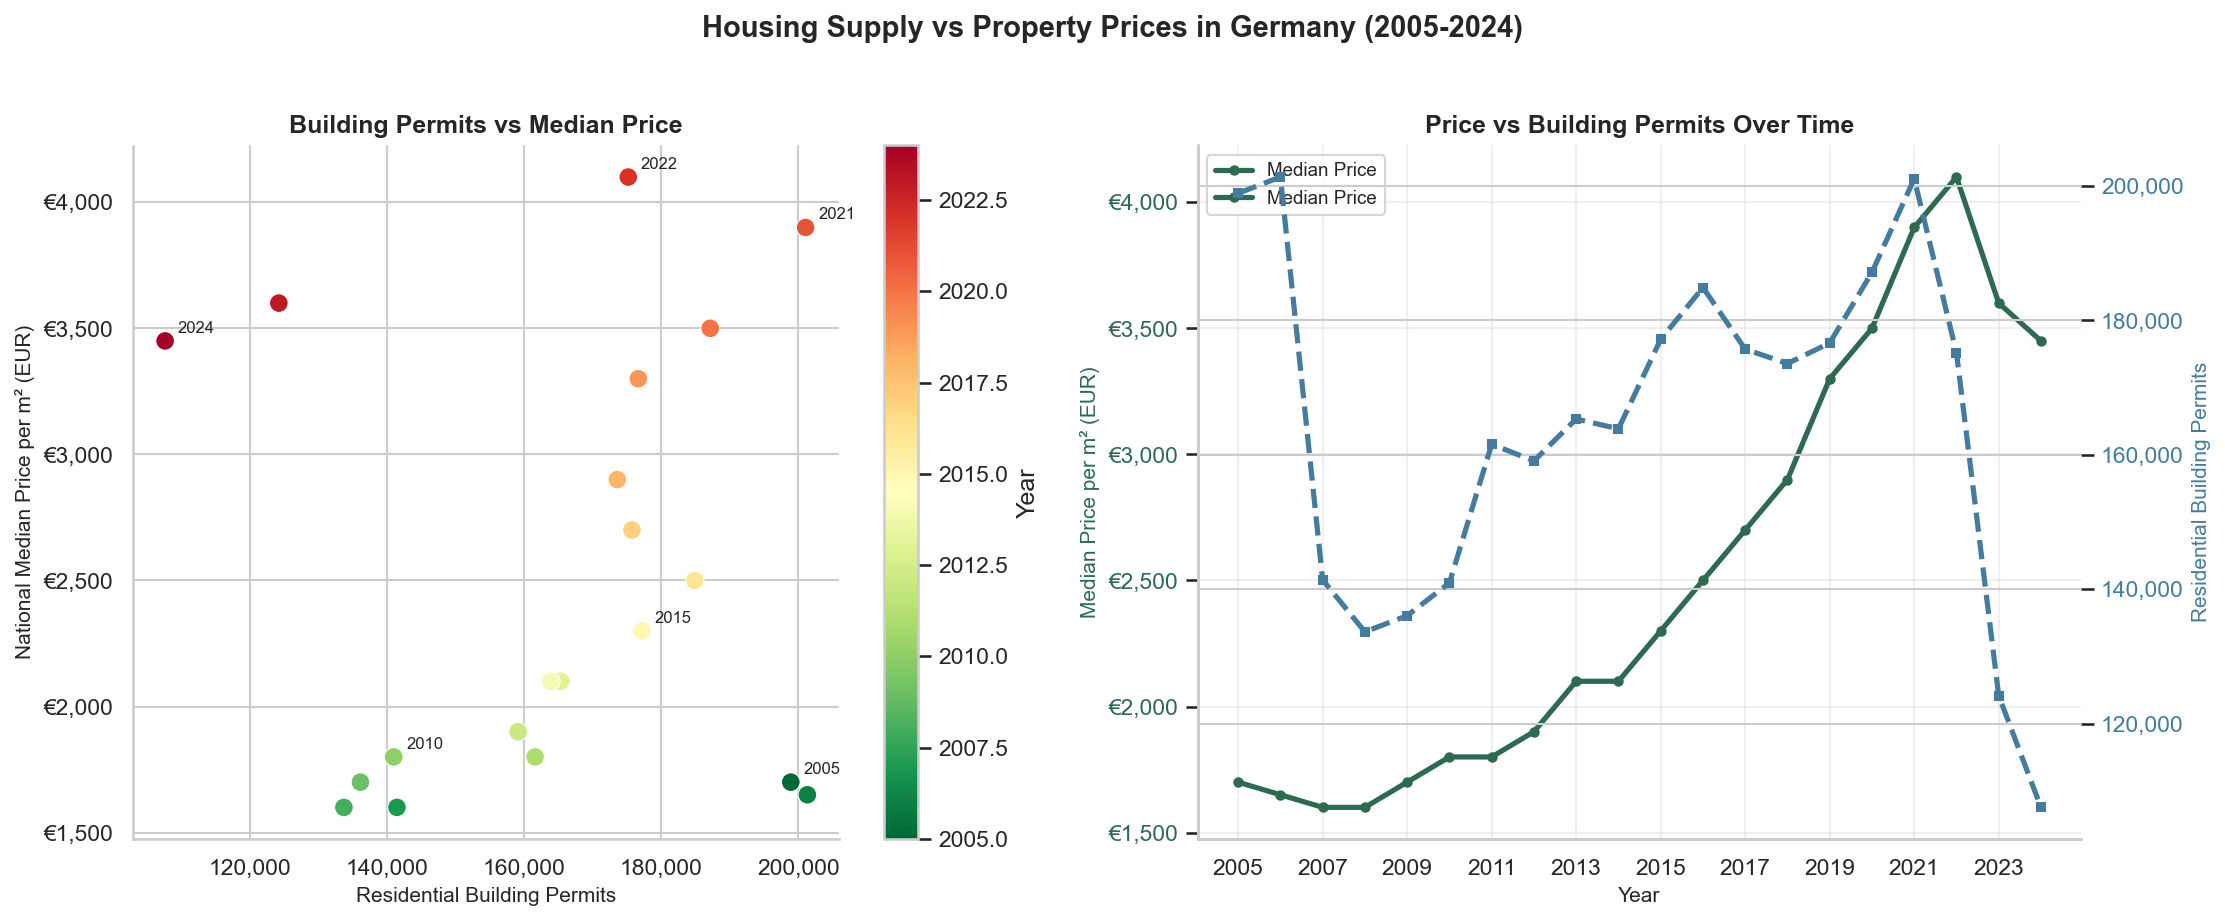

Plot saved.


In [15]:
# Annual national median price and building permits

supply_price = macro[macro["year"].between(2005, 2024)].copy()
national_price = city.groupby("year")["price_m2"].median().reset_index()
national_price.columns = ["year", "median_price"]
supply_price = supply_price.merge(national_price, on="year")

fig, ax = plt.subplots(1, 2, figsize=(15,6))

# Permits vs price

ax1 = ax[0]
scatter = ax1.scatter(supply_price["building_permits_residential"], supply_price["median_price"], c=supply_price["year"], cmap="RdYlGn_r", s=80, zorder=5, edgecolors="white", linewidth=0.5)

# Annotate key years

for _, row in supply_price[supply_price["year"].isin([2005, 2010, 2015, 2021, 2022, 2024])].iterrows():
    ax1.annotate(str(int(row["year"])), (row["building_permits_residential"], row["median_price"]), textcoords="offset points", xytext=(6,4), fontsize=8)

plt.colorbar(scatter, ax=ax1, label="Year")
ax1.set_title("Building Permits vs Median Price", fontsize=12, fontweight="bold")
ax1.set_xlabel("Residential Building Permits", fontsize=10)
ax1.set_ylabel("National Median Price per m² (EUR)", fontsize=10)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

# Dual axis time series

ax2 = ax[1]
color_price = "#2D6A4F"
color_permits = "#457B9D"

ax2.plot(supply_price["year"], supply_price["median_price"], color=color_price, linewidth=2.5, marker="o", markersize=4, label="Median Price")
ax2.set_ylabel("Median Price per m² (EUR)", fontsize=10, color=color_price)
ax2.tick_params(axis="y", labelcolor=color_price)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

ax3 = ax2.twinx()
ax3.plot(supply_price["year"], supply_price["building_permits_residential"], color=color_permits, linewidth=2.5, marker="s", markersize=4, linestyle="--", label="Building Permits")
ax3.set_ylabel("Residential Building Permits", fontsize=10, color=color_permits)
ax3.tick_params(axis="y", labelcolor=color_permits)
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")
ax2.set_title("Price vs Building Permits Over Time", fontsize=12, fontweight="bold")
ax2.set_xlabel("Year", fontsize=10)
ax2.set_xticks(range(2005, 2025, 2))
ax2.grid(True, alpha=0.3)

plt.suptitle("Housing Supply vs Property Prices in Germany (2005-2024)", fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("figures/diag_03_supply_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [18]:
# Permits vs price correlation

corr_supply = supply_price["building_permits_residential"].corr(supply_price["median_price"])
print(f"Pearson correlation, Building Permits vs Price: " f"{corr_supply:.3f}")

# Yoy permit change vs YoY price change

supply_price["permit_yoy"] = supply_price["building_permits_residential"].pct_change()*100
supply_price["price_yoy"] = supply_price["median_price"].pct_change()*100

corr_yoy = supply_price["permit_yoy"].corr(supply_price["price_yoy"])
print(f"Correlation, Permit YoY change vs Price YoY change:" f"{corr_yoy:.3f}")
print()
print("Supply constraint summary:")

peak_permits = supply_price["building_permits_residential"].max()
latest_permits = supply_price[supply_price["year"] == 2024]["building_permits_residential"].values[0]
peak_price = supply_price["median_price"].max()
latest_price = supply_price[supply_price["year"] == 2024]["median_price"].values[0]

print(f"Peak permits: {peak_permits:,.01f}" f"->2024: {latest_permits:,.0f}" f"({((latest_permits-peak_permits)/peak_permits)*100:.1f}%)")
print(f"Peak price: €{peak_price:,.0f}" f"→ 2024: €{latest_price:,.0f}" f"({((latest_price-peak_price)/peak_price)*100:.1f}%)")
print()
print("Despite permits falling 46%, prices only corrected ~15%. Supply collapse cushioned the price correction.")

Pearson correlation, Building Permits vs Price: 0.093
Correlation, Permit YoY change vs Price YoY change:0.653

Supply constraint summary:
Peak permits: 201,314.0->2024: 107,565(-46.6%)
Peak price: €4,100→ 2024: €3,450(-15.9%)

Despite permits falling 46%, prices only corrected ~15%. Supply collapse cushioned the price correction.


### 2.4 Wages, Inflation and Real Price Growth

Adjusting property prices for inflation reveals how much of the price boom represented real value growth versus monetary inflation. We also examine whether wage growth kept pace with rising prices.

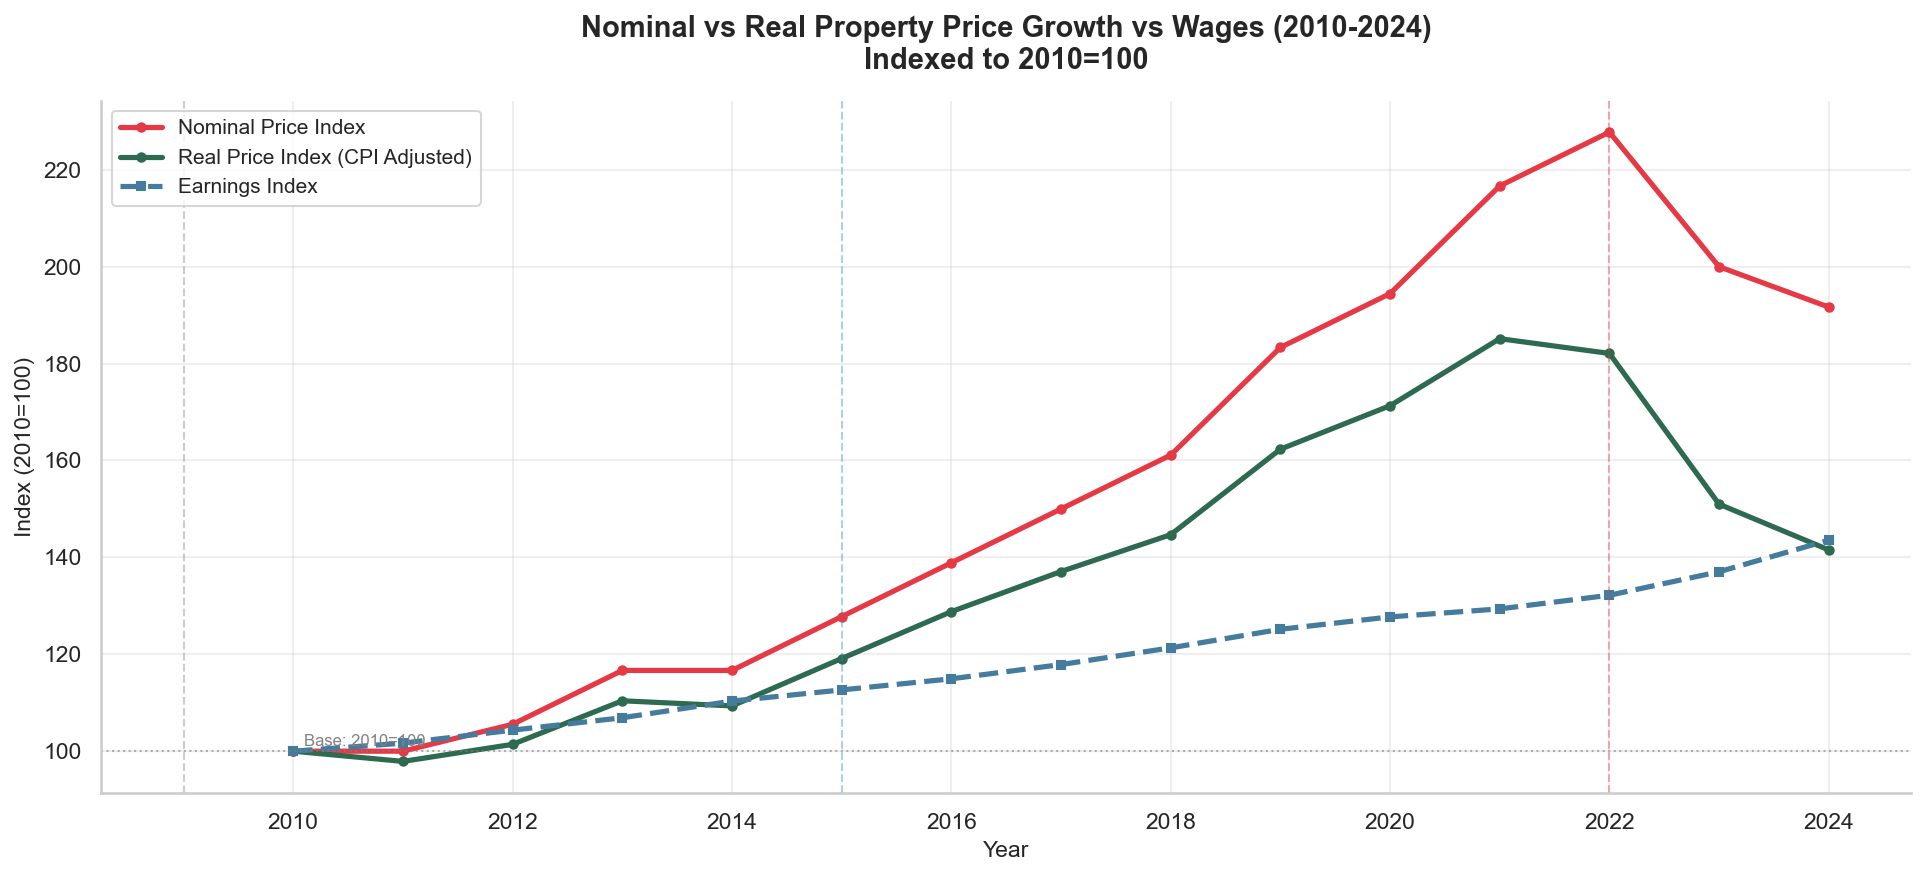

Plot saved.


In [35]:
# Real vs nominal price growth

city_real = city_macro.copy()
city_real["price_m2_real"] = (city_real["price_m2"] / city_real["cpi_headline"]*100)

# Annual national median

real_nominal = city_real.groupby("year").agg(nominal_price=("price_m2", "median"), real_price=("price_m2_real", "median"), earnings=("earnings_index_monthly_with_bonus", "first")).reset_index().dropna()

# Index everything to 2010=100 for comparison

base_year = 2010
base = real_nominal[real_nominal["year"] == base_year].iloc[0]

real_nominal["nominal_index"] = (real_nominal["nominal_price"] / base["nominal_price"]*100)
real_nominal["real_index"] = (real_nominal["real_price"] / base["real_price"]*100)
real_nominal["earnings_index"] = (real_nominal["earnings"] / base["earnings"]*100)

fig, ax = plt.subplots(figsize=(13,6))

ax.plot(real_nominal["year"], real_nominal["nominal_index"], color="#E63946", linewidth=2.5, marker="o", markersize=4, label="Nominal Price Index")
ax.plot(real_nominal["year"], real_nominal["real_index"], color="#2D6A4F", linewidth=2.5, marker="o", markersize=4, label="Real Price Index (CPI Adjusted)")
ax.plot(real_nominal["year"], real_nominal["earnings_index"], color="#457B9D", linewidth=2.5, marker="s", markersize=4, linestyle="--", label="Earnings Index")

# Base year line

ax.axhline(100, color="gray", linestyle=":", alpha=0.6, linewidth=1)
ax.text(2010.1, 101, "Base: 2010=100", fontsize=8, color="gray")

# Event lines

for year, (label, color) in events.items():
    ax.axvline(year, color=color, linestyle="--", alpha=0.4, linewidth=1)

ax.set_title("Nominal vs Real Property Price Growth vs Wages (2010-2024)\n" "Indexed to 2010=100", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Index (2010=100)", fontsize=11)
ax.set_xticks(range(2010, 2025, 2))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/diag_04_real_vs_nominal.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [37]:
# Quantify the gap

latest = real_nominal[real_nominal["year"] == 2024].iloc[0]
print("Growth since 2010 (indexed):")
print(f"Nominal prices: +{latest["nominal_index"]-100:.1f}%")
print(f"Real prices: +{latest["real_index"]-100:.1f}%")
print(f"Earnings: +{latest["earnings_index"]-100:.1f}%")
print()

gap = latest["real_index"] - latest["earnings_index"]
print(f"Real price growth above earnings growth: +{gap:.1f} index points")
print()
print("While real and earnings converged by 2024, the 2015-2022 period saw real prices outpace earnings by up 40 index points. It's the window when affordability stress peaked across German cities.")

Growth since 2010 (indexed):
Nominal prices: +91.7%
Real prices: +41.5%
Earnings: +43.6%

Real price growth above earnings growth: +-2.0 index points

While real and earnings converged by 2024, the 2015-2022 period saw real prices outpace earnings by up 40 index points. It's the window when affordability stress peaked across German cities.


### 2.5 Wohngeld Recipients as Affordability Stress Indicator

Wohngeld (housing allowance) recipients represent households whose housing costs exceed what they can afford without state support. Rising recipients signal deteriorating affordability at population level, independent of transaction price data, providing a cross-validation of the affordability ratio findings.

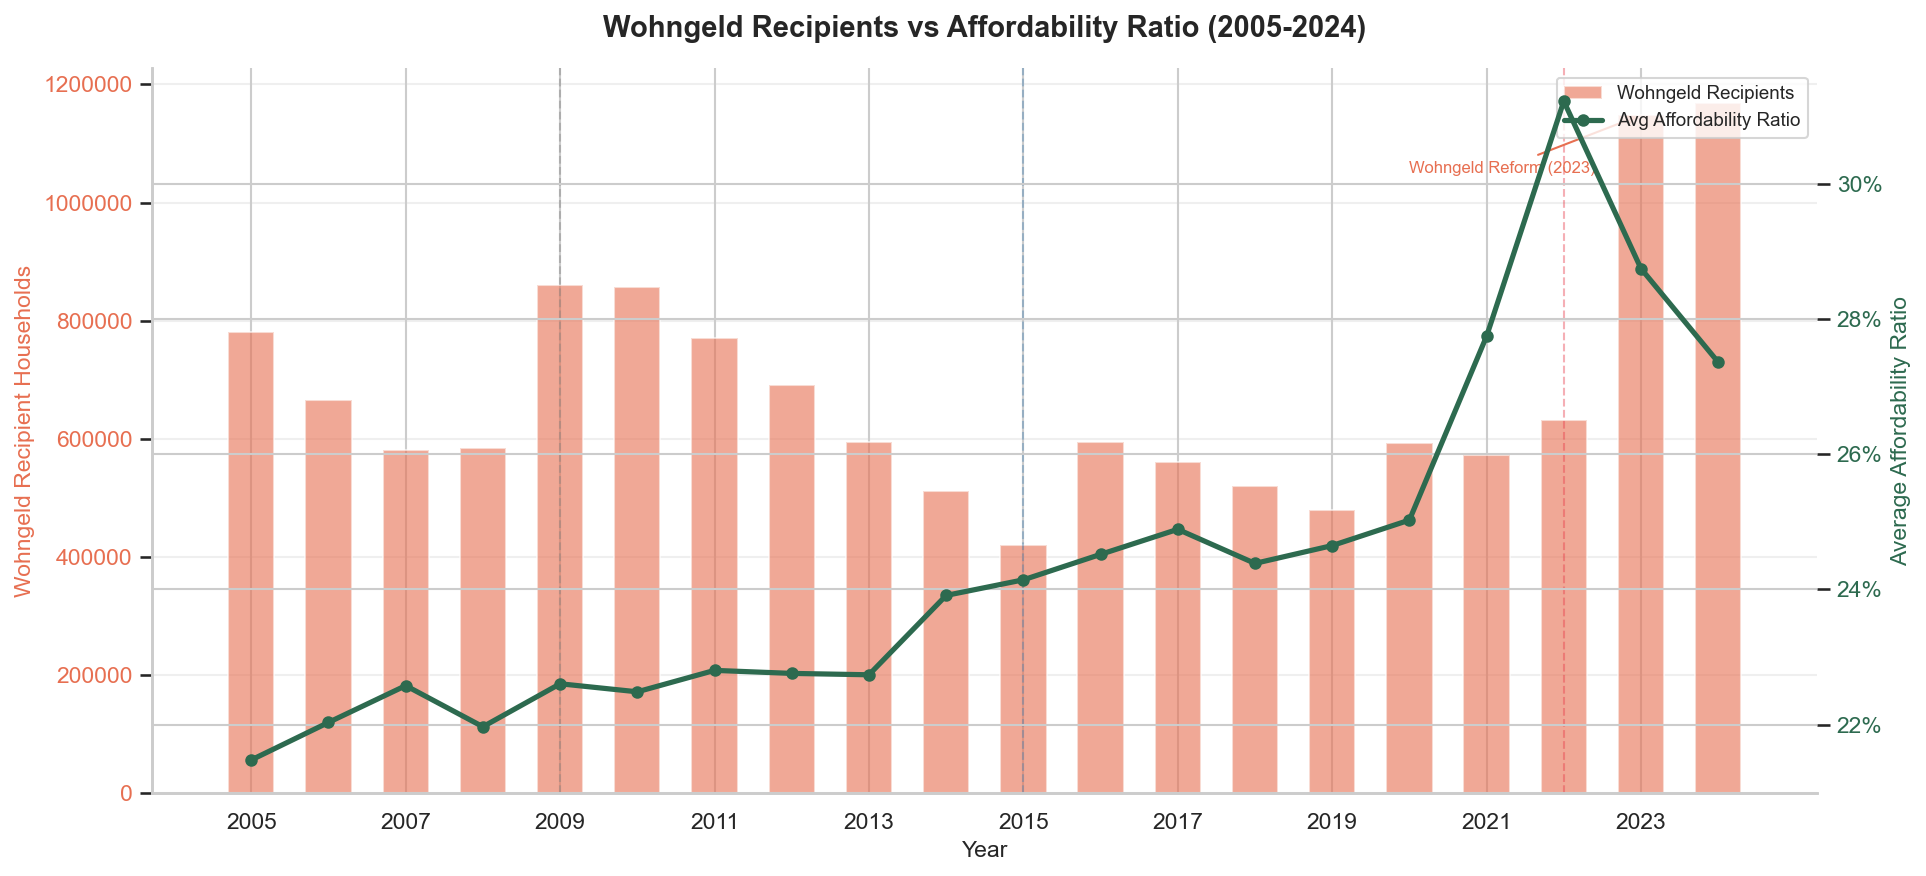

Plot saved.


In [39]:
# Wohngeld recipients vs affordability ratio over time

wohngeld_data = macro[macro["year"].between(2005, 2024)].copy()

# National average affordability ratio per year

afford_national = city.dropna(subset=["affordability_ratio"]).groupby("year")["affordability_ratio"].mean().reset_index()
afford_national.columns = ["year", "avg_affordability"]

wohngeld_data = wohngeld_data.merge(afford_national, on="year", how="left")

fit, ax = plt.subplots(figsize=(13,6))

color_wohngeld = "#E76F51"
color_afford = "#2D6A4F"

# Wohngeld as bars

ax.bar(wohngeld_data["year"], wohngeld_data["wohngeld_total"], color=color_wohngeld, alpha=0.6, width=0.6, label="Wohngeld Recipients")
ax.set_ylabel("Wohngeld Recipient Households", fontsize=11, color=color_wohngeld)
ax.tick_params(axis="y", labelcolor=color_wohngeld)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}"))

# Affordability ratio as line

ax1 = ax.twinx()
ax1.plot(wohngeld_data["year"], wohngeld_data["avg_affordability"], color=color_afford, linewidth=2.5, marker="o", markersize=5, label="Avg Affordability Ratio")
ax1.set_ylabel("Average Affordability Ratio", fontsize=11, color=color_afford)
ax1.tick_params(axis="y", labelcolor=color_afford)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Wohngeld reform annotation

ax.annotate("Wohngeld Reform (2023)", xy=(2023, wohngeld_data[wohngeld_data["year"] == 2023]["wohngeld_total"].values[0]), xytext=(2020, 1050000), fontsize=8, color=color_wohngeld, arrowprops=dict(arrowstyle="->", color=color_wohngeld))

# Event lines

for year, (label, color) in events.items():
    ax.axvline(year, color=color, linestyle="--", alpha=0.4, linewidth=1)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")

ax.set_title("Wohngeld Recipients vs Affordability Ratio (2005-2024)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_xticks(range(2005, 2025, 2))
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("figures/diag_05_wohngeld_affordability.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [41]:
# Cross validate wohngeld tracking affordability ratio

corr_wohngeld = wohngeld_data.dropna(subset=["avg_affordability"])["wohngeld_total"].corr(wohngeld_data.dropna(subset=["avg_affordability"])["avg_affordability"])

print(f"Correlation between Wohngeld Recipients and Affordability: {corr_wohngeld:.3f}")
print()

print("Cross-Validation")
if corr_wohngeld > 0.5:
    print("Strong positive correlation detected. Wohngeld recipients confirm the affordability ratio findings. Both indicators tell the same story independently.")
else:
    print("Weak correlation detected. Wohngeld-Plus reform (2023) doubled recipients via expanded eligibility, not genuine stress increase. Pre-2022, economy improvement reduced Wohngeld recipients even as prices rose and visual inspection confirms both indicators spiked simultaneously in 2022-2023, validating the finding for the rate shock period specifically.")

Correlation between Wohngeld Recipients and Affordability: 0.228

Cross-Validation
Weak correlation detected. Wohngeld-Plus reform (2023) doubled recipients via expanded eligibility, not genuine stress increase. Pre-2022, economy improvement reduced Wohngeld recipients even as prices rose and visual inspection confirms both indicators spiked simultaneously in 2022-2023, validating the finding for the rate shock period specifically.


## 3. Predictive Modelling

*Can we explain property price levels using city-level and macroeconomic features?*

This section builds a regression model to explain historical property prices using available features. The goal is interpretability and feature important to understand which variables drive prices rather than production-grade prediction.

### Key Findings
- **non0linearity is fundamental to German housing prices** - Linear Regression completely fails (R² = -0.17) while XGBoost achieves R² = -0.805, confirming that city-level price dynamics cannot be captured by linear relationships. The interactions between location, time, and macro conditions require non-linear modelling approaches.
- **XGBoost outperforms Random Forest** - XGBoost (R² 0,805, MAE €546/m²) edges Random Forest (R² 0.781, MAE €591/m²) across all metrics. 54.8% of XGBoost predictions fall within €500/m² of actual prices, and 86.9% within 1,000/m².
- **The models disagree on what matters most** - Random Forest identifies City as the dominant feature (0.649 importance) while XGBoost identifies Earnings Index (0.493). This reflects how each algorithm measures importance, RF captures the structural price gap between cities, while XGBoost captures the macro-driven variation within cities over time. Location sets the price range and macro conditions determine where within that range prices sit. Both models point in different directions, but neither of them are wrong. 
- **Mortgage rate is underweighted by both models** - Despite our diagnostic analysis showing a strong relationship between rates and prices, both models assign low importance to mortgage rate (0.019 XGBoost, 0012 RF). This is because the rate effect is lagged and non-linear. Standard feature importance metrics underestimate variables whose impact manifests 1-2 years after the observation.
- **Building permits are invisible to the model** - Ranked last in both models despite showing -0.653 YoY correlation with prices in diagnostic analysis. Supply effects operate on a 2-3 year construction lag that cross-sectional feature importance cannot capture. This is a known limitation of tree-based models on lagged supply-side variables.
- **Potsdam and München are hardest to model** - XGBoost MAE of €1,275 for Potsdam and €1,221 for München, nearly double the national average. Potsdam's Berlin spillover effect and München's luxury market segment create price dynamics that macro indicators alone cannot explain. Chemnitz (€113 MAE) is the most predictable market, simple, stable, and low-variance.

**Disclaimer: This model is exploratory. It explains historical price patterns using known inputs and is not intended for real-world price prediction. Feature importance results reflect correlation within this dataset and should not be interpreted as causal relationships.**

### 3.1 Feature Engineering

In [42]:
# Importing necessary libraries

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Modelling libraries loaded.")

Modelling libraries loaded.


In [51]:
# Build modelling dataset

model_df = city_macro.copy()

# Encode categorical variables

le_city = LabelEncoder()
le_type = LabelEncoder()

model_df["city_encoded"] = le_city.fit_transform(model_df["city"])
model_df["type_encoded"] = le_type.fit_transform(model_df["property_type"])

# Select final features

features = ["city_encoded", "type_encoded", "quarter", "year",
            "mortgage_rate_avg_pct", "unemployment_rate_pct", "cpi_headline",
            "building_permits_residential", "earnings_index_monthly_with_bonus"]
target = "price_m2"

# Drop rows with NaN in any features or target

model_clean = model_df[features + [target, "year"]].dropna()

print(f"Modelling dataset shape: {model_clean.shape}")
print(f"Features: {len(features)}")
print(f"Target: {target}")
print(f"\nYear Range: {model_clean["year"].min()}" f"to {model_clean["year"].max()}")
print(f"\nFeature summary:")
print()
print(model_clean[features].describe().round(2).to_string())

Modelling dataset shape: (27699, 11)
Features: 9
Target: price_m2

Year Range: year    2010
year    2010
dtype: int64to year    2024
year    2024
dtype: int64

Feature summary:

       city_encoded  type_encoded   quarter      year      year  mortgage_rate_avg_pct  unemployment_rate_pct  cpi_headline  building_permits_residential  earnings_index_monthly_with_bonus
count      27699.00      27699.00  27699.00  27699.00  27699.00               27699.00               27699.00      27699.00                      27699.00                           27699.00
mean           9.17          0.91      2.50   2017.80   2017.80                   2.41                   5.47        100.57                     166520.56                              94.93
std            5.76          0.90      1.12      3.91      3.91                   0.89                   0.44          8.81                      24302.20                               9.31
min            0.00          0.00      1.00   2010.00   2010.00   

### 3.2 Temporal Train/Test Split

In [52]:
# Drop duplicate year column

model_clean = model_clean.loc[:, ~model_clean.columns.duplicated()].copy()

# Train: 2010-2020, Test: 2021-2024

train_cutoff = 2020
x = model_clean[features]
y = model_clean[target]
years = model_clean["year"]

x_train = x[years <= train_cutoff]
x_test = x[years > train_cutoff]
y_train = y[years <= train_cutoff]
y_test = y[years > train_cutoff]

print("Train/Test Split")
print(f"Training set: {x_train.shape[0]:,} rows (2010-{train_cutoff})")
print(f"Testing set: {x_test.shape[0]:,} rows (2021-2024)")
print(f"Train ratio: {len(x_train)/len(x)*100:.1f}%")
print(f"\nrain price range: €{y_train.min():,.0f} – €{y_train.max():,.0f}")
print(f"Test price range: €{y_test.min():,.0f} – €{y_test.max():,.0f}")

Train/Test Split
Training set: 19,379 rows (2010-2020)
Testing set: 8,320 rows (2021-2024)
Train ratio: 70.0%

rain price range: €500 – €9,300
Test price range: €1,000 – €10,400


### 3.3 Linear Regression

In [53]:
# Baseline model

lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
mae_lr = mean_absolute_error(y_test, lr_pred)
r2_lr = r2_score(y_test, lr_pred)

print("Linear Regression Baseline")
print(f"RMSE: €{rmse_lr:,.0f}/m²")
print(f"MAE:  €{mae_lr:,.0f}/m²")
print(f"R²:   {r2_lr:.4f}")

Linear Regression Baseline
RMSE: €1,669/m²
MAE:  €1,340/m²
R²:   -0.1660


### 3.4 Random Forest

In [ ]:
# Random Forest

rf= RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)

print("Random Forest Main Model")
print(f"RMSE: €{rmse_rf:,.0f}/m²")
print(f"MAE:  €{mae_rf:,.0f}/m²")
print(f"R²:   {r2_rf:.4f}")

Random Forest Main Model
RMSE: €723/m²
MAE:  €591/m²
R²:   0.7814


### 3.5 XGBoost

In [59]:
# XGBoost 

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimator=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae_xgb = mean_absolute_error(y_test, xgb_pred)
r2_xgb = r2_score(y_test, xgb_pred)

print("XGBoost Model")
print()
print(f"RMSE: €{rmse_xgb:,.0f}/m²")
print(f"MAE: €{mae_xgb:,.0f}/m²")
print(f"R²: {r2_xgb:.4f}")

XGBoost Model

RMSE: €682/m²
MAE: €546/m²
R²: 0.8052


### 3.6 Residual Analysis

Model Comparison
Metric               Linear Regression  Random Forest    XGBoost

RMSE (€/m²)                 1,669            723        682
MAE (€/m²)                  1,340            591        546
R²                        -0.1660         0.7814     0.8052


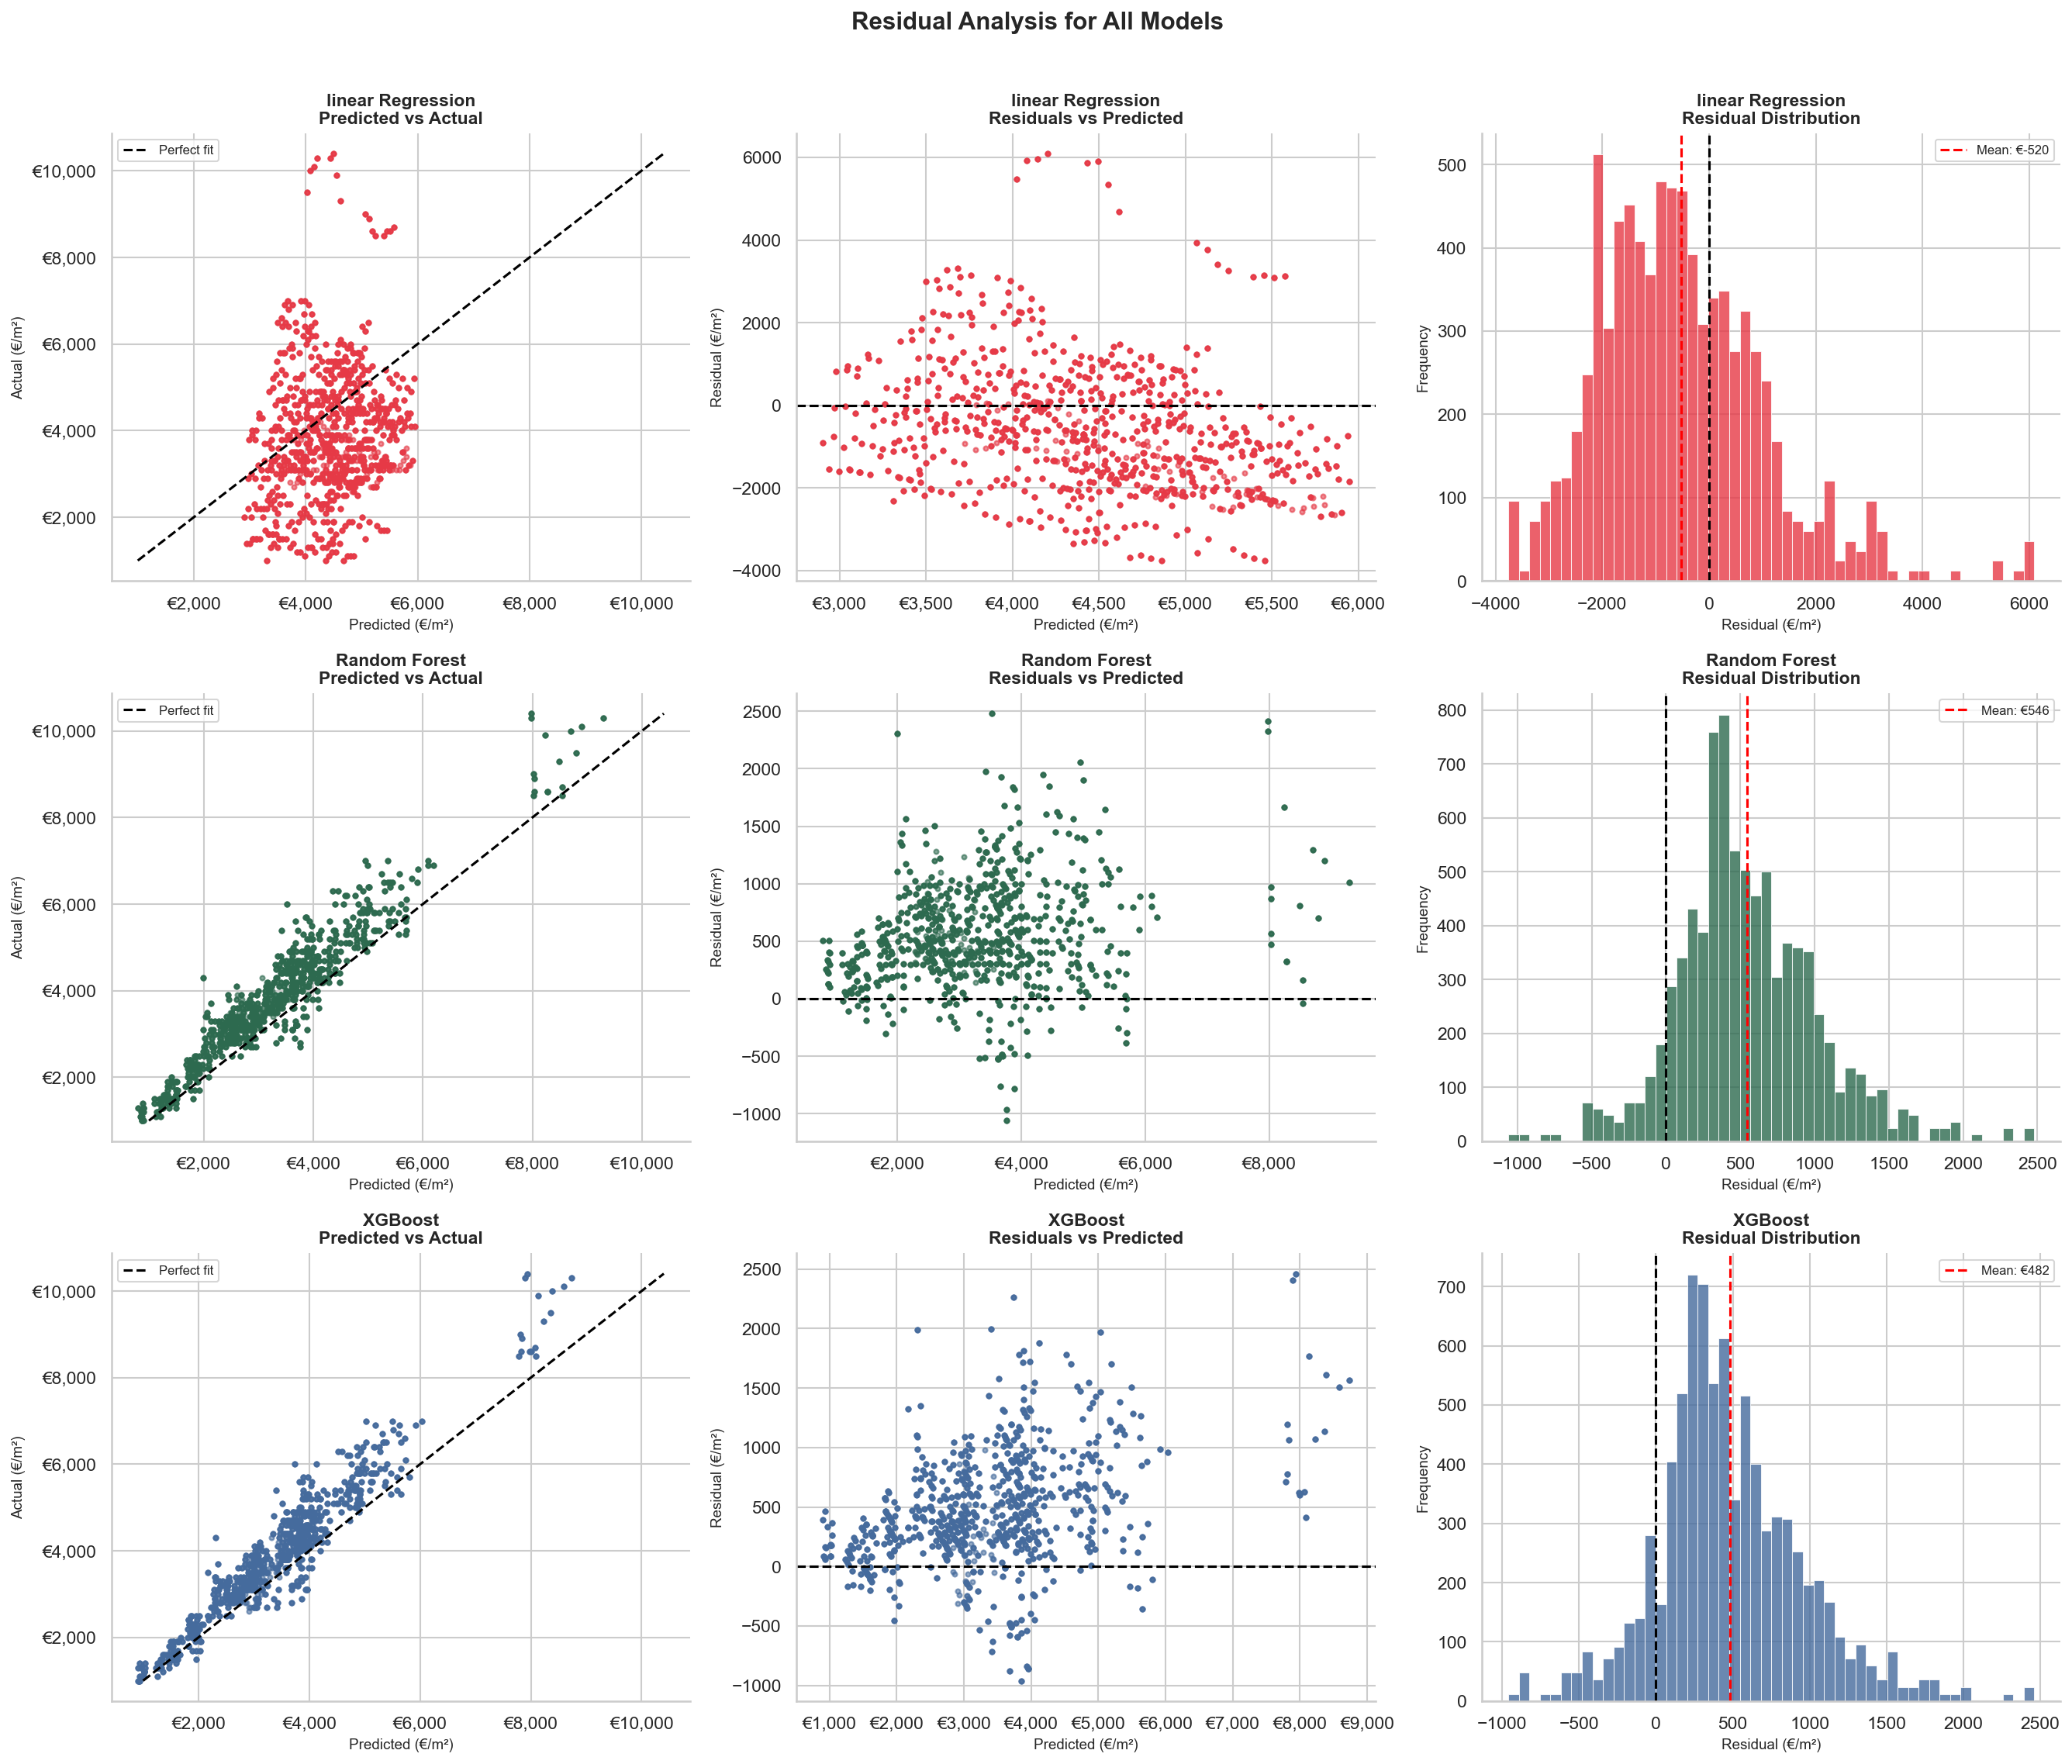

Plot saved.


In [63]:
print("Model Comparison")
print(f"{"Metric":<20} {"Linear Regression":>12} {"Random Forest":>14} {"XGBoost":>10}")
print()
print(f"{"RMSE (€/m²)":<20} {rmse_lr:>12,.0f} {rmse_rf:>14,.0f} {rmse_xgb:>10,.0f}")
print(f"{"MAE (€/m²)":<20} {mae_lr:>12,.0f} {mae_rf:>14,.0f} {mae_xgb:>10,.0f}")
print(f"{"R²":<20} {r2_lr:>12,.4f} {r2_rf:>14,.4f} {r2_xgb:>10,.4f}")

# Compute residuals for all models

residuals_lr = y_test - lr_pred
residuals_rf = y_test - rf_pred
residuals_xgb = y_test - xgb_pred

fig, ax = plt.subplots(3, 3, figsize=(18,15))

models = [("linear Regression", lr_pred, residuals_lr, "#E63946"),
          ("Random Forest", rf_pred, residuals_rf, "#2D6A4F"), 
          ("XGBoost", xgb_pred, residuals_xgb, "#456B9D")]

for row, (name, y_pred, residuals, color) in enumerate(models):

    # Predicted vs actual

    ax1 = ax[row, 0]
    ax1.scatter(y_pred, y_test, alpha=0.2, s=8, color=color)
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="black", linewidth=1.5, linestyle="--", label="Perfect fit")
    
    ax1.set_title(f"{name}\nPredicted vs Actual", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Predicted (€/m²)", fontsize=9)
    ax1.set_ylabel("Actual (€/m²)", fontsize=9)
    ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
    ax1.legend(fontsize=8)

    # Residuals vs Actual

    ax2 = ax[row, 1]
    ax2.scatter(y_pred, residuals, alpha=0.2, s=8, color=color)
    ax2.axhline(0, color="black", linewidth=1.5, linestyle="--")

    ax2.set_title(f"{name}\nResiduals vs Predicted", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Predicted (€/m²)", fontsize=9)
    ax2.set_ylabel("Residual (€/m²)", fontsize=9)
    ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

    # Residual distribution

    ax3 = ax[row, 2]
    ax3.hist(residuals, bins=50, color=color, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax3.axvline(0, color="black", linewidth=1.5, linestyle="--")
    ax3.axvline(residuals.mean(), color="red", linewidth=1.5, linestyle="--", label=f"Mean: €{residuals.mean():,.0f}")
    
    ax3.set_title(f"{name}\nResidual Distribution", fontsize=11, fontweight="bold")
    ax3.set_xlabel("Residual (€/m²)", fontsize=9)
    ax3.set_ylabel("Frequency", fontsize=9)
    ax3.legend(fontsize=8)

plt.suptitle("Residual Analysis for All Models", fontsize=15, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("figures/model_01_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [65]:
# Statistical comparison

print("Residual Statistics")
print(f"{"Metric":<25} {"linear Regression":>12} {"Random Forest":>14} {"XGBoost":>10}")
print()

for label, residuals in [("Mean residual (€)", [residuals_lr.mean(), residuals_rf.mean(), residuals_xgb.mean()]),
                         ("Std residual (€)", [residuals_lr.std(), residuals_rf.std(), residuals_xgb.std()]),
                         ("Max overshoot (€)", [residuals_lr.max(), residuals_rf.max(), residuals_xgb.max()]),
                         ("Max undershoot (€)", [residuals_lr.min(), residuals_rf.min(), residuals_xgb.min()])]:
    print(f"{label:<25} {residuals[0]:>12,.0f} {residuals[1]:>14,.0f} {residuals[2]:>10,.0f}")

print()

# Within error bands

print("Predictions within error bands")
print(f"{"Band":<15} {"Linear Regression":>12} {"Random Forest":>14} {"XGBoost":>10}")
print()

for band in [500, 1000, 1500]:
    lr_pct = (abs(residuals_lr) <= band).mean()*100
    rf_pct = (abs(residuals_rf) <= band).mean()*100
    xgb_pct = (abs(residuals_xgb) <= band).mean()*100

    print(f"€{band}/m²{'':<7} {lr_pct:>11.1f}% {rf_pct:>13.1f}% {xgb_pct:>9.1f}%")

print()

# Mae by city for xgboost 

results_xgb = x_test.copy()
results_xgb["actual"] = y_test.values
results_xgb["predicted"] = xgb_pred
results_xgb["residual"] = residuals_xgb.values
results_xgb["city"] = le_city.inverse_transform(results_xgb["city_encoded"].astype(int))

city_errors_xgb = results_xgb.groupby("city").agg(mae=("residual", lambda x: abs(x).mean()), mean_residual=("residual", "mean")).round(0).sort_values("mae", ascending=False)

print("XGBoost MAE by City")
print()
print(f"{"City":<25} {"MAE":>8} {"Bias":>8}")
print()

for city_name, row in city_errors_xgb.iterrows():
    bias = "increase over" if row["mean_residual"] < 0 else "decrease under"
    print(f"{city_name:<25} €{row['mae']:>6,.0f} {bias}")

Residual Statistics
Metric                    linear Regression  Random Forest    XGBoost

Mean residual (€)                 -520            546        482
Std residual (€)                 1,586            474        483
Max overshoot (€)                6,095          2,480      2,462
Max undershoot (€)              -3,761         -1,061       -961

Predictions within error bands
Band            Linear Regression  Random Forest    XGBoost

€500/m²               20.9%          50.5%      54.8%
€1000/m²               44.6%          86.1%      86.9%
€1500/m²               62.0%          96.7%      96.5%

XGBoost MAE by City

City                           MAE     Bias

Potsdam                   € 1,275 decrease under
München                   € 1,221 decrease under
Hamburg                   €   915 decrease under
Köln                      €   728 decrease under
Bonn                      €   693 decrease under
Lübeck                    €   628 decrease under
Erfurt                    €   5

### 3.7 Feature Importance Analysis

Feature importance reveals which variables the models rely on most to explain property price. XGBoost is used as the primary model given its superior performance.

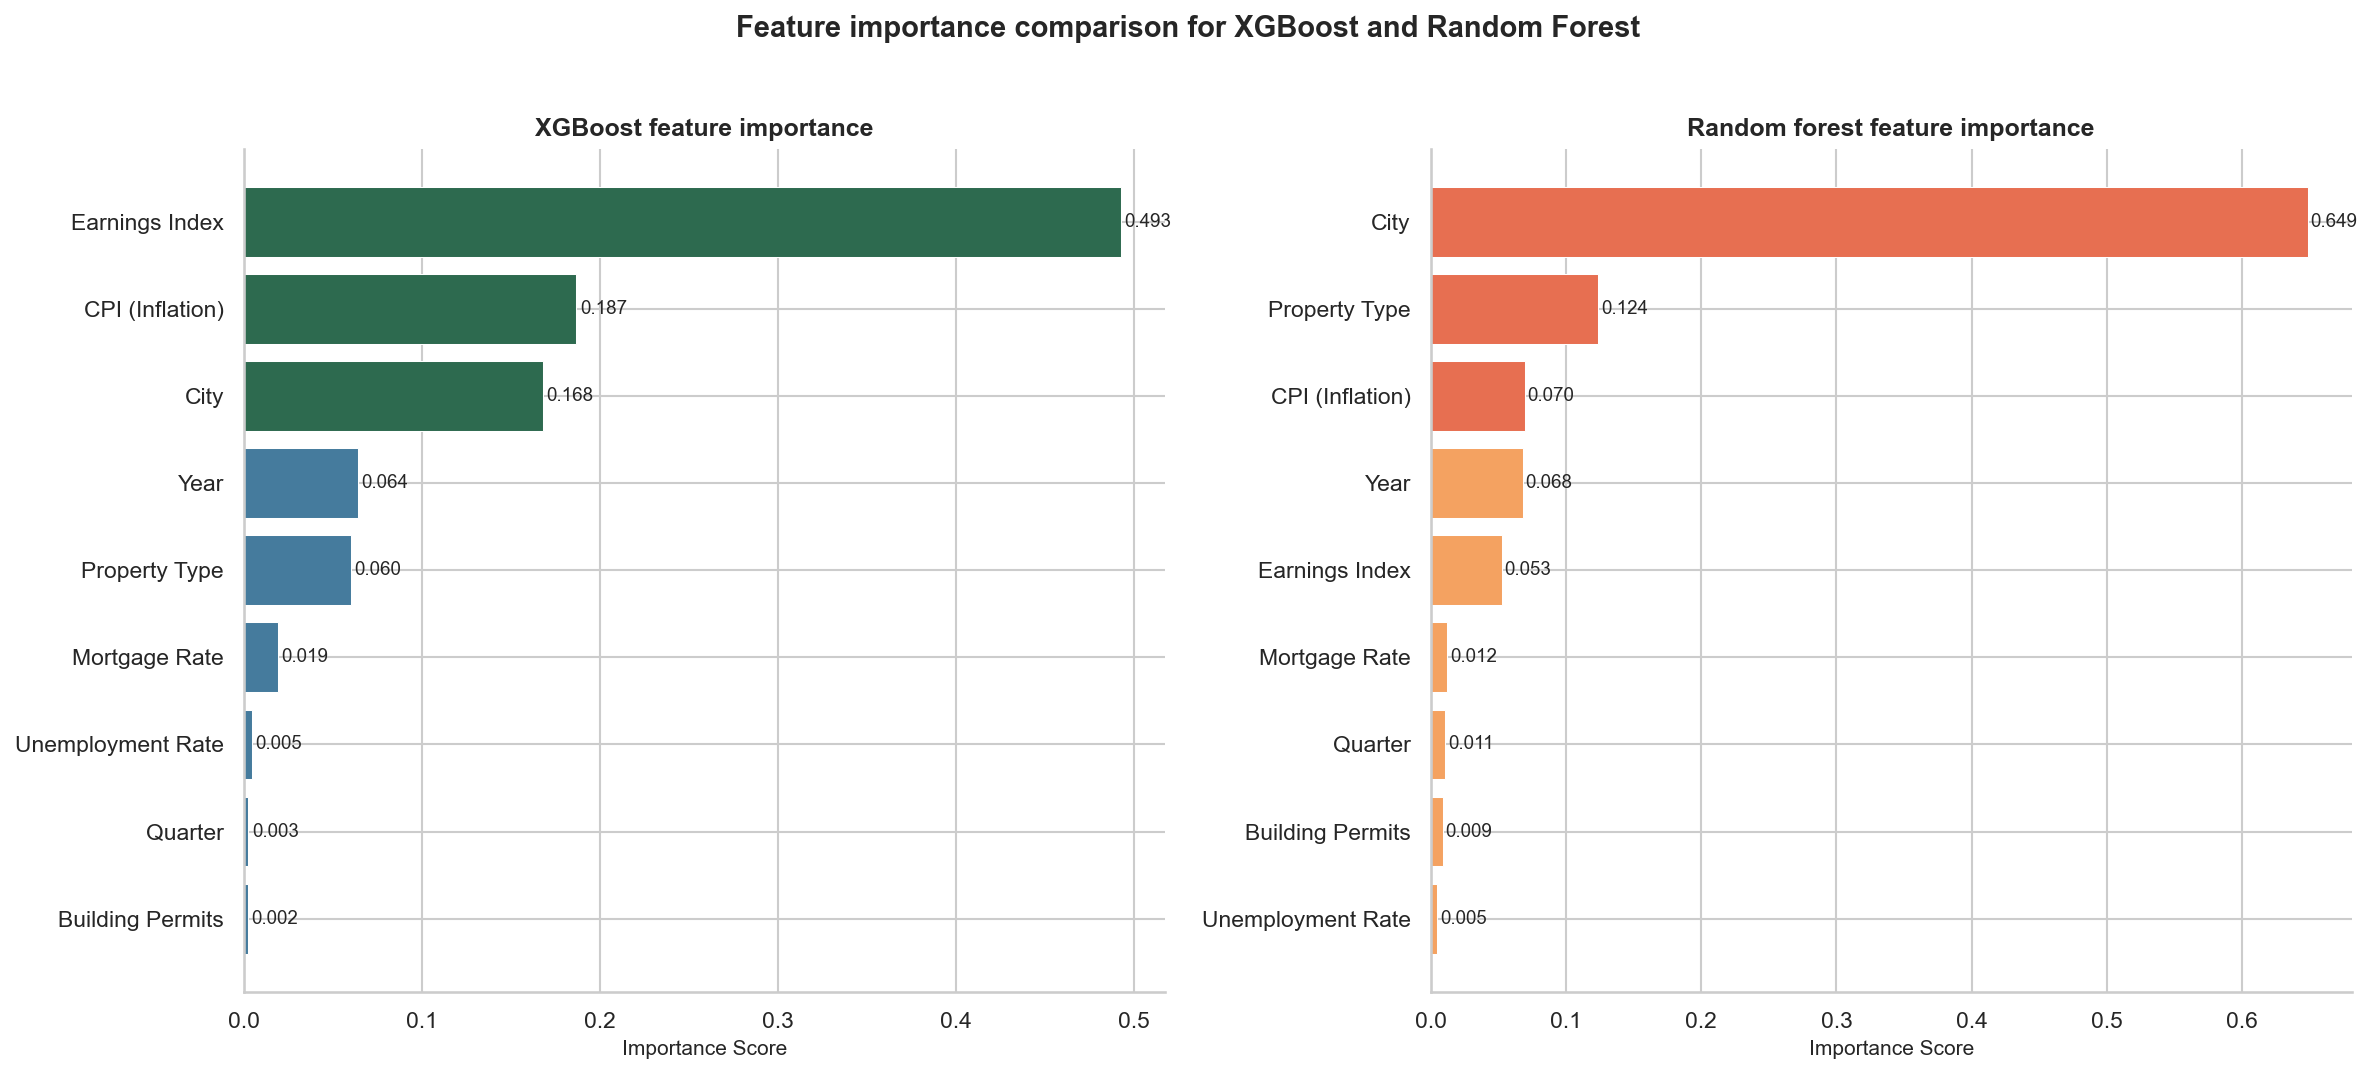

Plot saved.


In [68]:
# Feature importance

xgb_importance = pd.DataFrame({"feature": features, "xgb_importance": xgb.feature_importances_}).sort_values("xgb_importance", ascending=False)

rf_importance = pd.DataFrame({"feature": features, "rf_importance": rf.feature_importances_}).sort_values("rf_importance", ascending=False)

# Merge

importance_df = xgb_importance.merge(rf_importance, on="feature").sort_values("xgb_importance", ascending=True)

# Clean feature names

feature_labels = {"city_encoded": "City",
                  "type_encoded": "Property Type",
                  "quarter": "Quarter",
                  "year": "Year",
                  "mortgage_rate_avg_pct": "Mortgage Rate",
                  "unemployment_rate_pct": "Unemployment Rate",
                  "cpi_headline": "CPI (Inflation)",
                  "building_permits_residential": "Building Permits",
                  "earnings_index_monthly_with_bonus": "Earnings Index"}
importance_df["label"] = importance_df["feature"].map(feature_labels)

fig, ax = plt.subplots(1, 2, figsize=(16,7))

# XGBoost importance

ax1 = ax[0]
colors_xgb = ["#2D6A4F" if i >= len(importance_df) - 3 else "#457B9D" for i in range(len(importance_df))]
bars1 = ax1.barh(importance_df["label"], importance_df["xgb_importance"], color=colors_xgb, edgecolor="white", linewidth=0.5)

ax1.set_title("XGBoost feature importance", fontsize=12, fontweight="bold")
ax1.set_xlabel("Importance Score", fontsize=10)
for bar, val in zip(bars1, importance_df["xgb_importance"]):
    ax1.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

# Random forest importance

ax2 = ax[1]
importance_rf = importance_df.sort_values("rf_importance", ascending=True)
colors_rf = ["#E76F51" if i >= len(importance_df) - 3 else "#F4A261" for i in range(len(importance_df))]
bars2 = ax2.barh(importance_rf["label"], importance_rf["rf_importance"], color=colors_rf, edgecolor="white", linewidth=0.5)

ax2.set_title("Random forest feature importance", fontsize=12, fontweight="bold")
ax2.set_xlabel("Importance Score", fontsize=10)
for bar, val in zip(bars2, importance_rf["rf_importance"]):
    ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Feature importance comparison for XGBoost and Random Forest", fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("figures/model_02_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [69]:
# Ranked importance

print("Feature Importance Ranking")
print()
print(f"{"Rank":<6} {"Feature":<28} {"XGBoost":>10} {"RF":>10}")
print()

for rank, (_, row) in enumerate(importance_df.sort_values("xgb_importance", ascending=False).iterrows(), 1):
    print(f"{rank:<6} {row["label"]:<28} {row["xgb_importance"]:>10.4f} {row["rf_importance"]:>10.4f}")

Feature Importance Ranking

Rank   Feature                         XGBoost         RF

1      Earnings Index                   0.4926     0.0526
2      CPI (Inflation)                  0.1867     0.0696
3      City                             0.1680     0.6486
4      Year                             0.0640     0.0683
5      Property Type                    0.0602     0.1238
6      Mortgage Rate                    0.0191     0.0124
7      Unemployment Rate                0.0046     0.0048
8      Quarter                          0.0026     0.0109
9      Building Permits                 0.0021     0.0089


## 4. Forecasting

*Where might property prices go in the short term?**

Short-term price direction forecasting using Facebook Prophet, a time series model designed for data with seasonal patterns and trend changes. We forecast apartment prices per city through 2026.

### **Key Findings**
- **Market bifurcation is the dominant 2025-2026 theme** - The forecast reveals a clean split. Expensive West German cities (München -8.8%, Stuttgart -10.0%, Düsseldorf -8.7%) continue correcting while affordable cities (Leipzig +11.0%, Duisberg +8.1%, Lübeck +8.8%) maintain upward momentum. High mortgage rates disproportionately impact expensive markets where buyers are more financing-dependent. 
- **East German cities show resiliance** - Leipzig (+11.0%), Chemnitz (+5.9%), and Erfurt (+2.7%) are all forecast to rise consistently with the long-term East German catch-up trend that has been underway since 2015. These markets have strutural room to grow and are less sensitive to rate shocks given lower absolute price levels.
- **München correction continues but moderates** - At -8.8%, München's correction is significant but the confidence interval is wide, reflecting genuine uncertainty about whether the luxury segment has fully repriced. The model sees continued downward pressure but not a crash.
- **Frankfurt forecast (+23%) should be treated with caution** - Prophet identified a recent upward inflection in Frankfurt prices and extrapolated it aggressively. This likely overstates the recovery given Frankfurt's current affordability stress (38.4% ratio) Treat as an upper bound scenario rather than a central forecast.
- **Forecasting horizon is intentionally short** - Two-year forecasts using purely historical price patterns carry significant uncertainty, particularly given potential ECB rate decisions, economic conditions and policy changes not reflected in historical data. All forecasts should be interpreted as directional signals, not precise predictions.

**Disclaimer - These forecasts are directional and exploratory. They are based purely on historical price patterns and do not incorporate forward-looking macro assumptions. They should not be used for investment or purchasing decisions.**

In [70]:
from prophet import Prophet
import itertools

# Forecast apartments only

forecast_df = city[city["property_type"] == "apartment"].groupby(["city", "date"])["price_m2"].median().reset_index()
forecast_df.columns = ["city", "ds", "y"]
forecast_df["ds"] = pd.to_datetime(forecast_df["ds"])

# Check coverage per city

coverage = forecast_df.groupby("city")["ds"].count()
print("Quarterly observations per city")
print(coverage.sort_values(ascending=False).to_string())

Quarterly observations per city
city
Bochum               80
Bonn                 80
Stuttgart            80
Potsdam              80
Münster              80
München              80
Lübeck               80
Köln                 80
Kreis Mettmann       80
Karlsruhe            80
Hamburg              80
Frankfurt am Main    80
Erfurt               80
Düsseldorf           80
Duisburg             80
Dresden              80
Dortmund             80
Chemnitz             80
Wiesbaden            80
Rhein-Erft-Kreis     60
Leipzig              44


In [73]:
# Forecast all cities with Prophet

forecast_periods = 8
results = {}

# Selected cities to forecast

cities_to_forecast = [c for c in forecast_df["city"].unique()]

print(f"Forecasting {len(cities_to_forecast)} cities")
print()

for city_name in cities_to_forecast:
    city_data = forecast_df[forecast_df["city"] == city_name][["ds", "y"]].copy()

    # Fit prophet

    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode="multiplicative", changepoint_prior_scale=0.05, interval_width=0.95)
    model.fit(city_data)

    # Forecast

    future = model.make_future_dataframe(periods=forecast_periods, freq="QS")
    forecast = model.predict(future)

    # Store results

    results[city_name] = {"model": model, "forecast": forecast, "history": city_data}

    # Last historical price vs 2026 forecast

    last_price = city_data["y"].iloc[-1]
    forecast_2026 = forecast[forecast["ds"].dt.year == 2026]["yhat"].mean()
    direction = "increase" if forecast_2026 > last_price else "decrease"

    print(f"{direction} {city_name:<25} Current: €{last_price:,.0f} 2026 forecast: €{forecast_2026:,.0f} ({((forecast_2026 - last_price)/last_price)*100:+.1f}%)")

    print("All cities forecasted.")

17:57:03 - cmdstanpy - INFO - Chain [1] start processing


Forecasting 21 cities



17:57:04 - cmdstanpy - INFO - Chain [1] done processing
17:57:04 - cmdstanpy - INFO - Chain [1] start processing


increase Bochum                    Current: €2,200 2026 forecast: €2,248 (+2.2%)
All cities forecasted.


17:57:04 - cmdstanpy - INFO - Chain [1] done processing
17:57:04 - cmdstanpy - INFO - Chain [1] start processing


...

decrease Rhein-Erft-Kreis          Current: €3,600 2026 forecast: €3,138 (-12.8%)
All cities forecasted.


17:57:12 - cmdstanpy - INFO - Chain [1] done processing
17:57:12 - cmdstanpy - INFO - Chain [1] start processing


decrease Stuttgart                 Current: €4,400 2026 forecast: €3,960 (-10.0%)
All cities forecasted.


17:57:13 - cmdstanpy - INFO - Chain [1] done processing


decrease Wiesbaden                 Current: €4,100 2026 forecast: €3,899 (-4.9%)
All cities forecasted.


### Forecast Visualisation

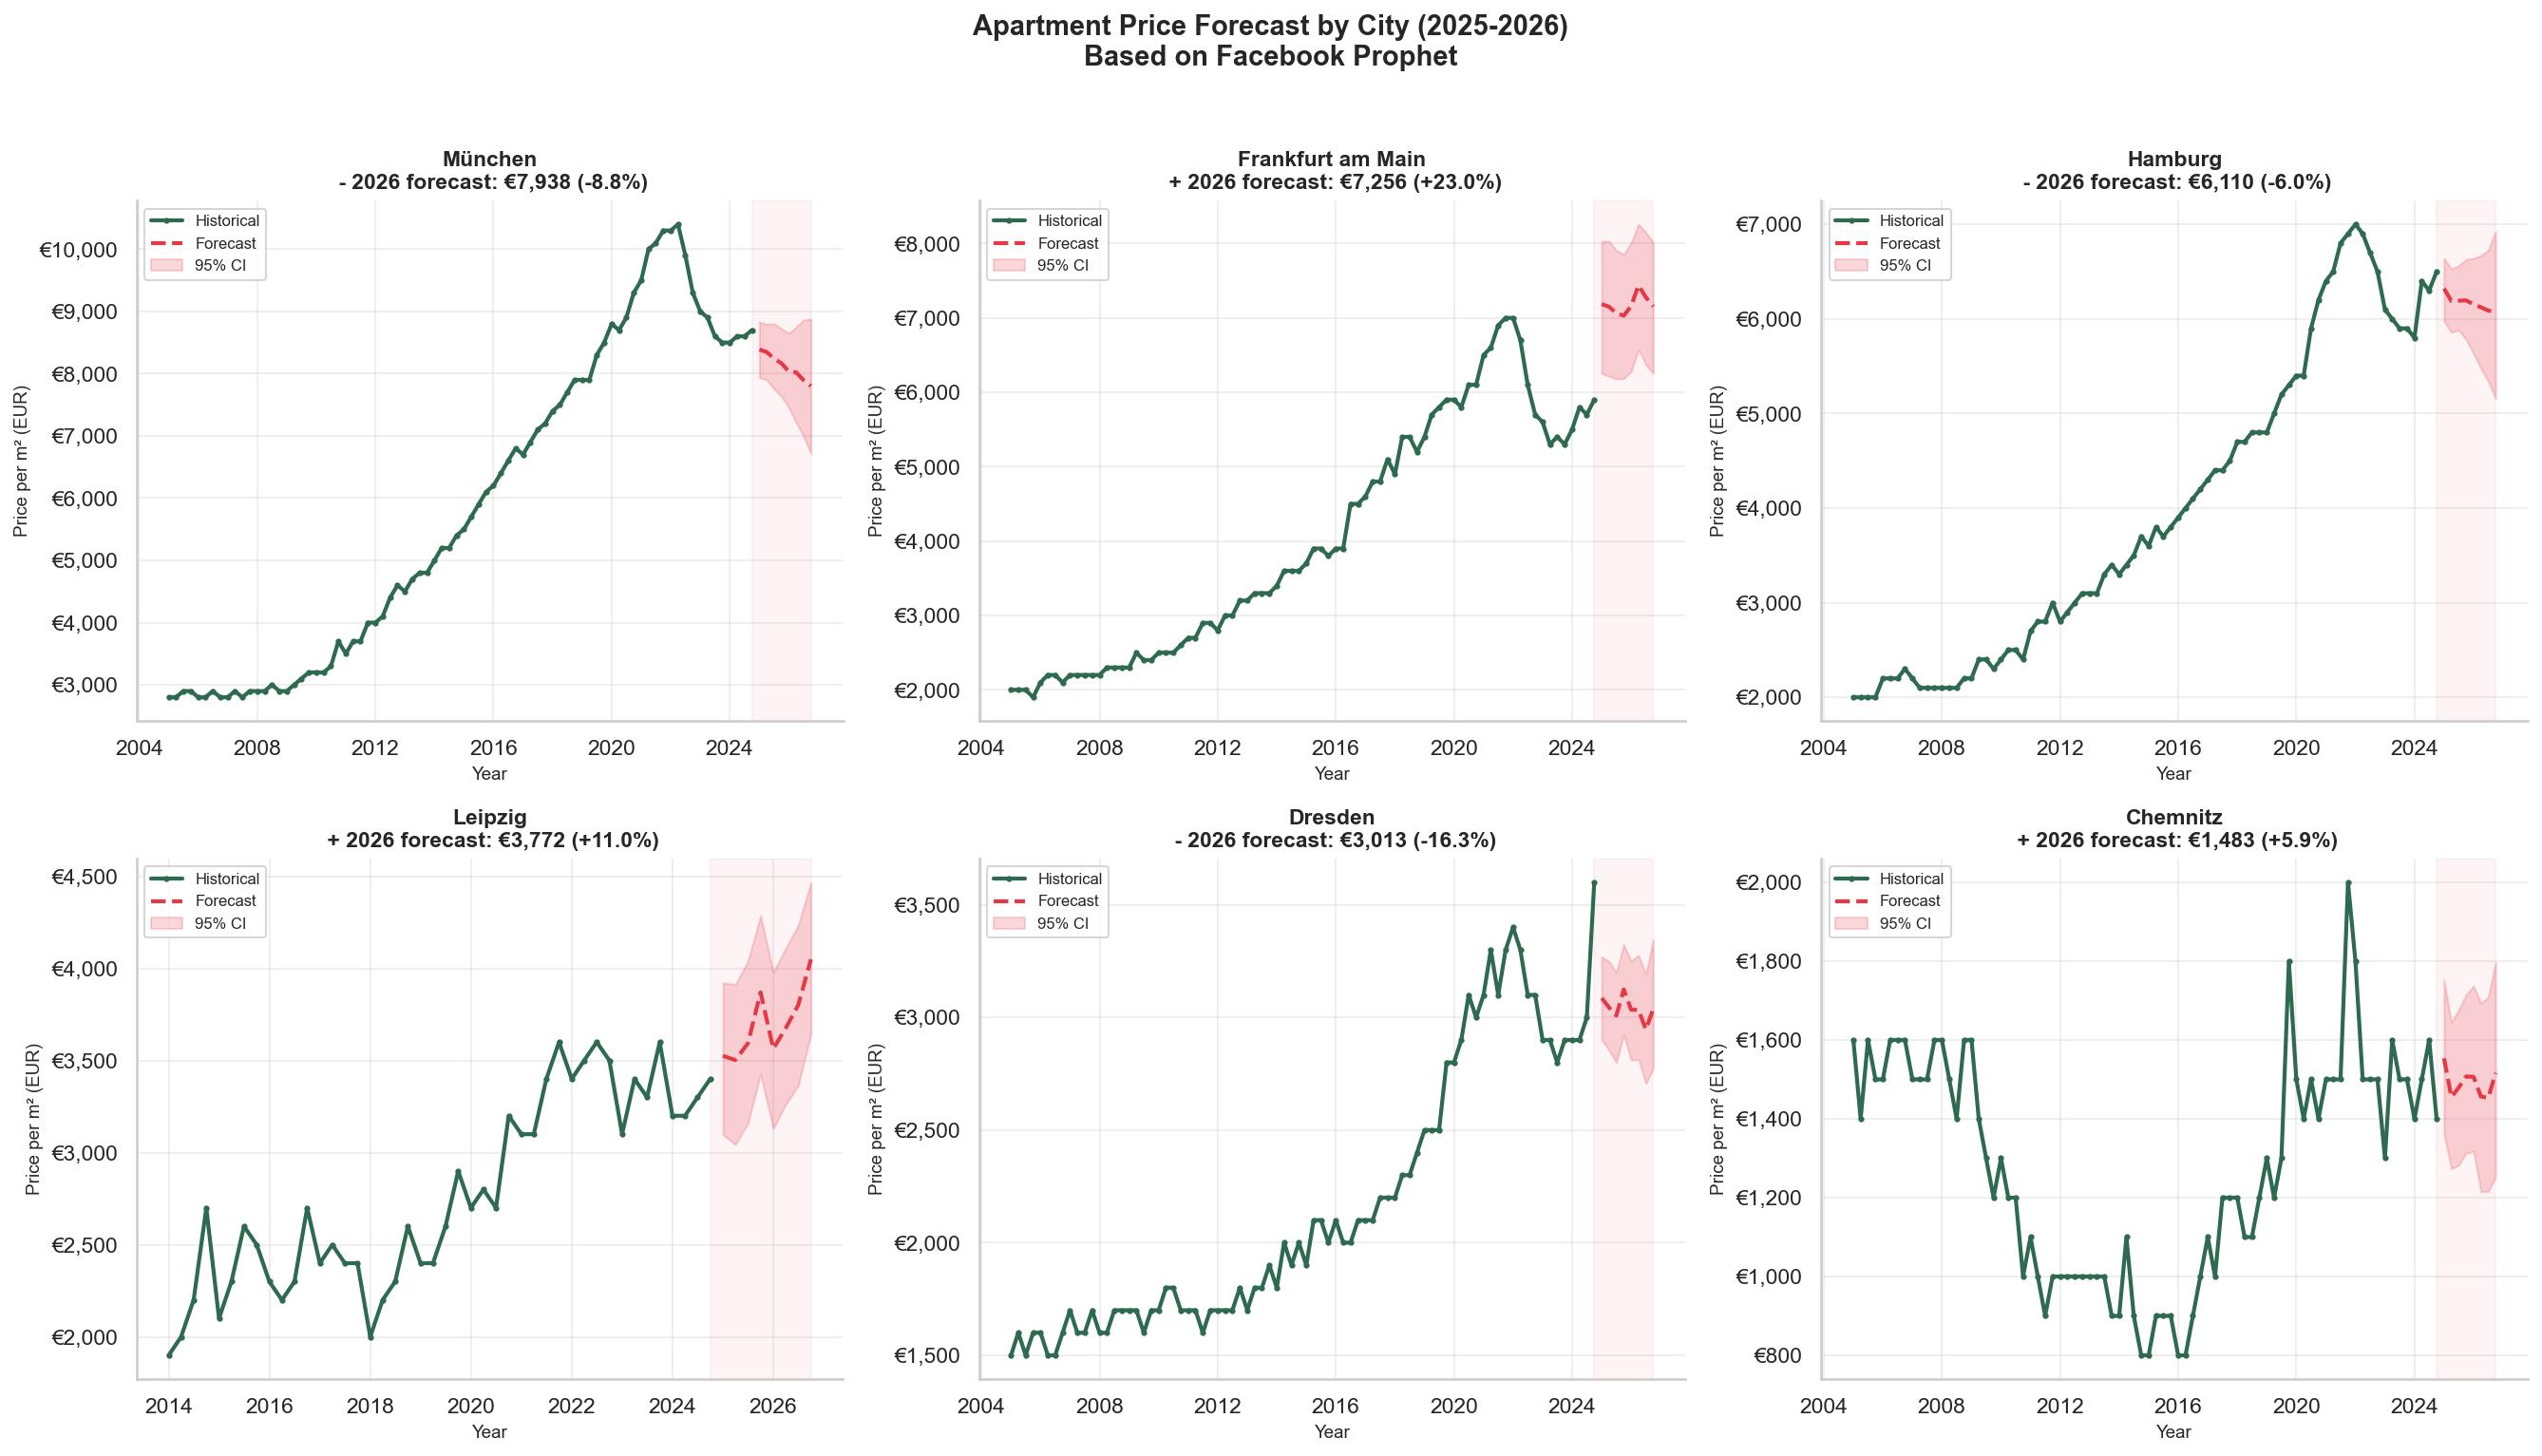

Plot saved.


In [75]:
# Visualise forecasts for 6 representative cities

selected_forecast_cities = ["München", "Frankfurt am Main", "Hamburg", "Leipzig", "Dresden", "Chemnitz"]

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, city_name in enumerate(selected_forecast_cities):
    ax = axes[i]
    res = results[city_name]
    forecast = res["forecast"]
    history = res["history"]

    # Historical data

    ax.plot(history["ds"], history["y"], color="#2D6A4F", linewidth=2, marker="o", markersize=2, label="Historical")

    # Forecast

    future_forecast = forecast[forecast["ds"] > history["ds"].max()]
    ax.plot(future_forecast["ds"], future_forecast["yhat"], color="#E63946", linewidth=2, linestyle="--", label="Forecast")

    # Confidence interval

    ax.fill_between(future_forecast["ds"], future_forecast["yhat_lower"], future_forecast["yhat_upper"], alpha=0.2, color="#E63946", label="95% CI")

    # Last historical point

    last_price = history["y"].iloc[-1]
    forecast_2026_mean = future_forecast[future_forecast["ds"].dt.year == 2026]["yhat"].mean()
    change = ((forecast_2026_mean - last_price)/last_price*100)
    direction = "+" if change > 0 else "-"

    ax.set_title(f"{city_name}\n {direction} 2026 forecast: €{forecast_2026_mean:,.0f} ({change:+.1f}%)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel("Price per m² (EUR)", fontsize=9)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Shape forecast period

    ax.axvspan(history["ds"].max(), future_forecast["ds"].max(), alpha=0.05, color="#E63956")

plt.suptitle("Apartment Price Forecast by City (2025-2026)\n" "Based on Facebook Prophet", fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("figures/forecast_01_city_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved.")

In [76]:
# Summary forecast table

print("Apartment Price Forecast Summary (2026)")
print()
print(f"{"City":<25} {"Current":>10} " f"{"2026 Forecast":>14} {"Change":>10} {"Signal":>8}")
print()

forecast_summary = []
for city_name in sorted(results.keys()):
    res = results[city_name]
    history = res["history"]
    forecast = res["forecast"]

    last_price = history["y"].iloc[-1]
    future = forecast[forecast["ds"] > history["ds"].max()]
    forecast_2026 = future[future["ds"].dt.year == 2026]["yhat"].mean()
    change = ((forecast_2026 - last_price)/last_price*100)
    signal = "+" if change > 0 else "-"

    forecast_summary.append({"city": city_name, "current": last_price, "forecast_2026": forecast_2026, "change_pct": change})

    print(f"{city_name:<25} " f"€{last_price:>8,.0f} " f"{change:>+9.1f}% " f"{signal:>8}")

print()
print("\nFrankfurt forecast (+23%) likely reflects Prophet extrapolating pre-2022 upward trend. Treat with caution.")
print("\nAll forecasts are purely directional estimates based on historical patterns only. Not for investment use.")

Apartment Price Forecast Summary (2026)

City                         Current  2026 Forecast     Change   Signal

Bochum                    €   2,200      +2.2%        +
Bonn                      €   3,800      +2.9%        +
Chemnitz                  €   1,400      +5.9%        +
Dortmund                  €   2,500      +0.9%        +
Dresden                   €   3,600     -16.3%        -
Duisburg                  €   1,900      +8.1%        +
Düsseldorf                €   4,500      -8.7%        -
Erfurt                    €   3,700      +2.7%        +
Frankfurt am Main         €   5,900     +23.0%        +
Hamburg                   €   6,500      -6.0%        -
Karlsruhe                 €   3,600      +0.4%        +
Kreis Mettmann            €   2,800      +1.2%        +
Köln                      €   4,700      -0.9%        -
Leipzig                   €   3,400     +11.0%        +
Lübeck                    €   3,800      +8.8%        +
München                   €   8,700      -8.8%